# NMDS, Heat Maps, and Bar plots of normalized abundance

This jupyter notebook will walk you through the data processing and visualization of proteome data measured from Ruegeria pomeroyi Strain DSS-3 under different media conditions, as conducted in the Master Thesis / Publication by Fadime R. Stemmer (2025): "The Exo-proteomic Framework for Nitrogen Acquisition from Proteinaceous Organic Matter in the Model Marine Heterotroph Ruegeria Pomeroyi DSS-3".

You should have opened this jupyter notebook after cloning the respective GitHub repository 'Rpom_Exoproteome' onto your computer. The file structure of this repo will be used in this code, so for this code to work, it is important that files are not moved or renamed. If you decide to move/rename the files, please adjust the jupyter notebook filepaths accordingly.

## Step 1: Import libraries
First we import all libraries for data import, manipulation, statistical analysis, and visualization.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import numpy.ma as ma 
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform, braycurtis
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from skbio.stats.distance import permanova, DistanceMatrix
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
from matplotlib import cm
from bokeh.io import show, output_file
from bokeh.models import ColumnDataSource
from bokeh.plotting import figure
import itertools

## Step 2: Import Files
Make sure that you ran the scripts in the folder 'fragpipe/' prior to this such that annotated proteome files (i.e. files with the extension '_annotated.txt' are present in the 'data/' folder.

In [2]:
'''
Function to load the data from _annotated.txt files as dictionary values and assign to key (= growth medium). 
If successful the function will prompt: "PROTEOME loaded into script!"

USAGE: load_data(folder='FOLDERNAME_CONTAINING_annotated_TXTFILES')
'''
proteome_dic = {}

def load_data(folder=''):
    proteome_dic = {}
    
    for file in glob.glob(os.path.join(folder, '*_annotated.txt')):
        parts = os.path.basename(file).replace('.txt', '').strip().split('_')
        
        # Default: just join everything from 2 to 5 like before
        medium_phase = '_'.join(parts[2:3])
        
        data = pd.read_csv(file, delimiter='\t')
        proteome_dic[medium_phase] = data
        print(f"{medium_phase} loaded into script!")
    
    return proteome_dic

In [3]:
proteome_dic=load_data('../data/proteomics/raw/')

ProMM-N+CSec loaded into script!
ProMM loaded into script!
ProMM-N+C loaded into script!
ProMMSec loaded into script!
ProMM+Cas loaded into script!


## Step 3: NMDS
Multidimensional scaling - or MDS - is a technique used for analyzing similarity or dissimilarity data. It attempts to model similarity or dissimilarity data as distances in a geometric space. The data can be ratings of similarity between objects, interaction frequencies of molecules, or trade indices between countries.

There exists two types of MDS algorithm: metric and non metric. In scikit-learn, the class MDS implements both. In Metric MDS, the input similarity matrix arises from a metric (and thus respects the triangular inequality), the distances between output two points are then set to be as close as possible to the similarity or dissimilarity data. In the non-metric version, the algorithms will try to preserve the order of the distances, and hence seek for a monotonic relationship between the distances in the embedded space and the similarities/dissimilarities.

Here we use Bray-Curtis Distance since we are dealing with spectral data (not counts).

This description was adapted from: https://scikit-learn.org/stable/modules/manifold.html#multidimensional-scaling

### Data pre-processing for NMDS
First we will need to modify our data for plotting. The following functions are used to filter proteins based on their presence in or absence from all replicates, and merges all samples into one dataframe to be used in downstream analyses. 

In [9]:
'''
The function filter_valid_proteins() is used to filter the results from proteomics such that proteins appearing in all or none of the 
triplicates are retained whereas proteins only present in one or two of the three samples are deemed unsignificant and removed from the 
dataset. This function is needed for the bar plots. 

USAGE: filter_valid_proteins(data_dic)

After the filtering step, we want to merge all individual data to one dataframe based on Accession number and Annotation. We use the 
function 'merge_data_dic()' for that.

USAGE: merge_data_dic(data_dic, trip_cols=('1', '2', '3'))
    * data_dic = dictionary containing keys = growth condition, and df = associated mass spec data in triplicates (1, 2, 3), annotations,
                 and accession numbers
    * trip_cols = triplicate columns. Should be 1, 2, 3 in each dictionary key - df pair. 

'''

def filter_valid_proteins(data_dic):
    for key, df in data_dic.items():
        triplicates = df[['1', '2', '3']] # extract the triplicate columns from the dictionary items
        # use mask to remove non-significant proteins based on absence/presence in replicates
        mask = triplicates.notna().all(axis=1) | triplicates.isna().all(axis=1)
        data_dic[key] = df[mask]
    return data_dic

proteome_dic=filter_valid_proteins(proteome_dic)
    
def merge_data_dic(data_dic, trip_cols=('1', '2', '3')):
    merged = None

    for key, df in data_dic.items():
        df = df.copy()
        # Rename only the triplicate columns that exist in this df
        rename_dict = {c: f"{c}_{key}" for c in trip_cols}
        df = df.rename(columns=rename_dict)

        if merged is None:
            merged = df
        else:
            merged = pd.merge(
                 merged,
                df,
                on=['Accession Number', 'Annotation'],
                how='outer'
            )
    return merged


merged = merge_data_dic(proteome_dic)
print(merged)

     Accession Number                                         Annotation  \
0             SPO0001  tRNA uridine 5-carboxymethylaminomethyl modifi...   
1             SPO0002  Ribosomal RNA small subunit methyltransferase ...   
2             SPO0003               Chromosome partitioning protein ParA   
3             SPO0004               Chromosome partitioning protein parB   
4             SPO0005                   DUF454 domain-containing protein   
...               ...                                                ...   
3880         SPOA0445                   Ferric uptake regulation protein   
3881         SPOA0446             Transcriptional regulator, LysR family   
3882         SPOA0449           Phytanoyl-CoA dioxygenase family protein   
3883         SPOA0451             Transcriptional regulator, MarR family   
3884         SPOA0452             Transcriptional regulator, MarR family   

      1_ProMM-N+CSec  2_ProMM-N+CSec  3_ProMM-N+CSec    1_ProMM    2_ProMM  \
0        

### NMDS Plots

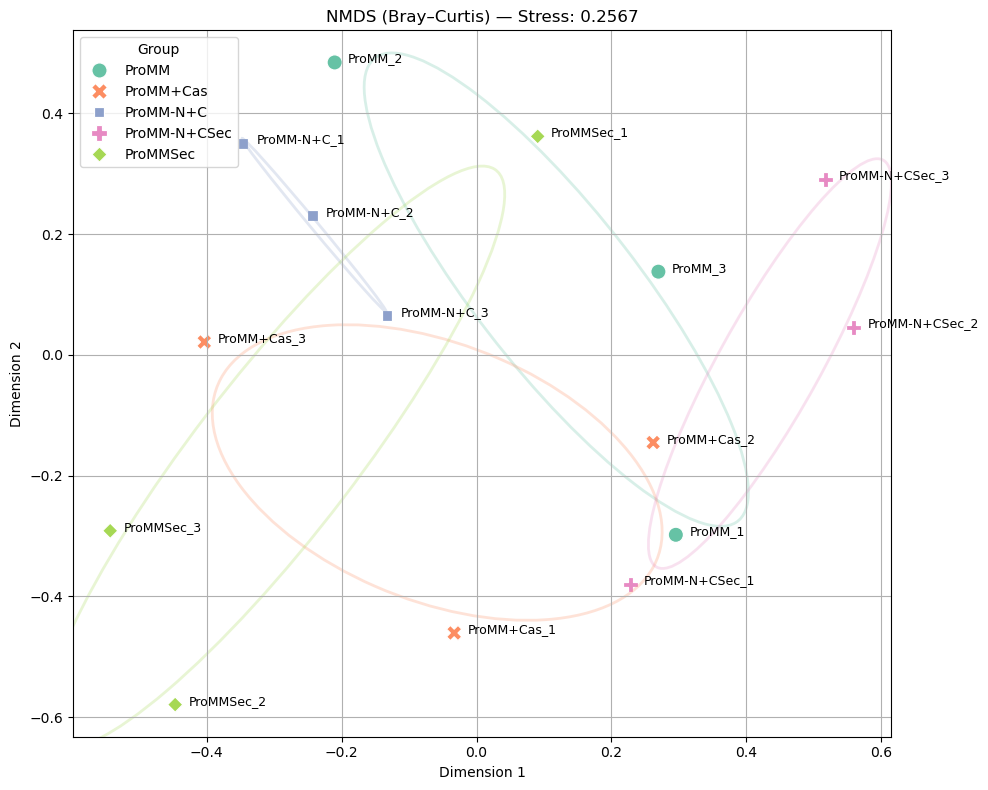


PERMANOVA Result:
method name                PERMANOVA
test statistic name         pseudo-F
sample size                       15
number of groups                   5
test statistic            174.526716
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object

NMDS Stress: 0.2567


In [16]:
def data_mod(df, chosen_suffixes=None):
    # Extract all suffixes that appear in df
    all_suffixes = sorted({ col.split('_')[1] for col in df.columns if '_' in col })

    # If user provided a subset, filter to it
    if chosen_suffixes is not None:
        suffixes = [s for s in all_suffixes if s in chosen_suffixes]
    else:
        suffixes = all_suffixes

    trip_cols = []
    labels = []

    for suffix in suffixes:
        cols = [f"{i}_{suffix}" for i in ['1', '2', '3']]
        trip_cols.extend(cols)
        labels.extend([f"{suffix}_{i}" for i in ['1', '2', '3']])

    # Filter out proteins with missing replicates in selected groups
    data = df[trip_cols].dropna()

    # Transpose
    data_T = data.T
    data_T.columns = [f"Prot_{i}" for i in range(data_T.shape[1])]
    data_T.index = labels

    return data_T, labels
    
data_T, labels = data_mod(merged)

def NMDS(data_T, labels):
    distance_matrix = squareform(pdist(data_T, metric='braycurtis'))

    # NMDS 
    nmds = MDS(
        n_components=2,
        dissimilarity='precomputed',
        metric=False,
        random_state=42
    )
    nmds_coords = nmds.fit_transform(distance_matrix)
    stress = nmds.stress_

    #PLOT NMDS
    df_plot = pd.DataFrame(nmds_coords, columns=['Dim1', 'Dim2'])
    df_plot['Sample'] = labels
    df_plot['Group'] = [lab.split('_')[0] for lab in labels]   # suffix grouping
    plt.figure(figsize=(10, 8))
    palette = sns.color_palette('Set2', len(df_plot['Group'].unique()))

    sns.scatterplot(
        data=df_plot,
        x='Dim1',
        y='Dim2',
        hue='Group',
        style='Group',
        s=120,
        palette=palette
    )

    # Add Ellipses
    def draw_ellipse(data, ax, edgecolor='black', alpha=0.25):
        if data.shape[0] < 2:
            return
        cov = np.cov(data.T)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals = vals[order]
        vecs = vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)  # 1 SD
        mean = data.mean(axis=0)
        ellipse = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=theta,
            edgecolor=edgecolor,
            facecolor='none',
            lw=2,
            alpha=alpha
        )
        ax.add_patch(ellipse)

    ax = plt.gca()
    for i, group in enumerate(df_plot['Group'].unique()):
        group_data = df_plot[df_plot['Group'] == group][['Dim1', 'Dim2']].values
        draw_ellipse(group_data, ax, edgecolor=palette[i])

    # Add Labels
    for i in range(len(df_plot)):
        plt.text(df_plot.Dim1[i] + 0.02, df_plot.Dim2[i], df_plot.Sample[i], fontsize=9)

    plt.title(f"NMDS (Bray–Curtis) — Stress: {stress:.4f}")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # PERMANOVA
    grouping = df_plot['Group'].tolist()
    dm = DistanceMatrix(distance_matrix, ids=labels)
    permanova_result = permanova(dm, grouping, permutations=999)

    print("\nPERMANOVA Result:")
    print(permanova_result)
    print(f"\nNMDS Stress: {stress:.4f}")

    return df_plot, stress, permanova_result
    
df_plot, stress, permanova_result = NMDS(data_T, labels)

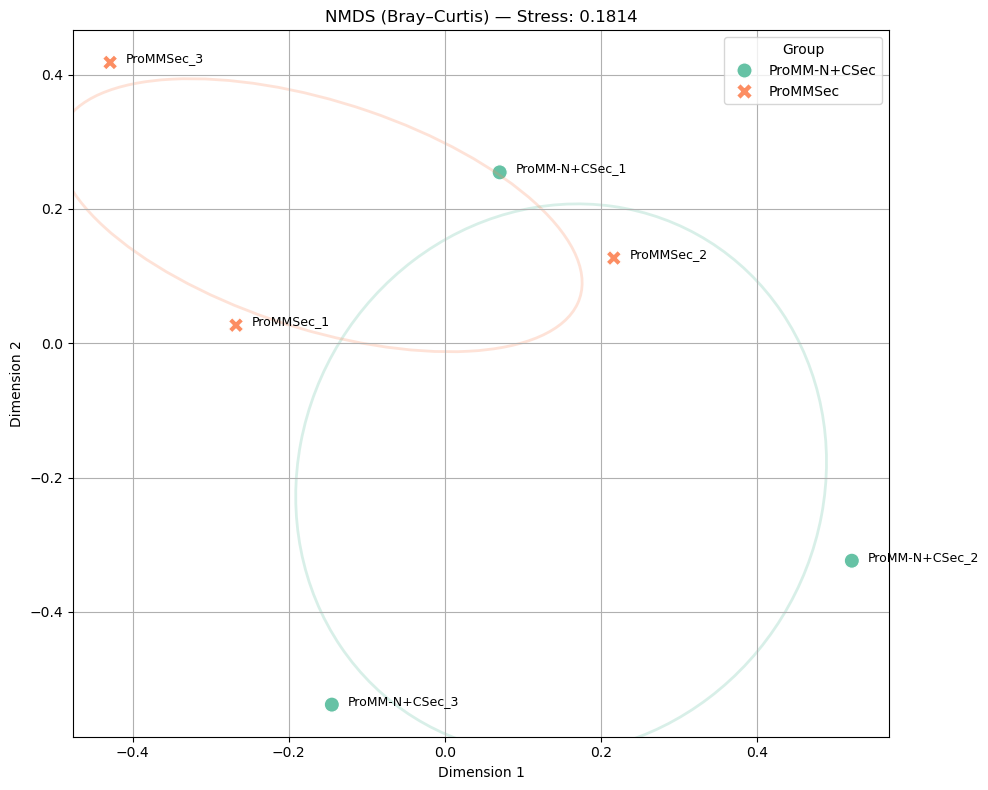


PERMANOVA Result:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                       6
number of groups                  2
test statistic            104.42562
p-value                       0.098
number of permutations          999
Name: PERMANOVA results, dtype: object

NMDS Stress: 0.1814


(       Dim1      Dim2          Sample         Group
 0  0.070348  0.254568  ProMM-N+CSec_1  ProMM-N+CSec
 1  0.521842 -0.323737  ProMM-N+CSec_2  ProMM-N+CSec
 2 -0.144845 -0.538035  ProMM-N+CSec_3  ProMM-N+CSec
 3 -0.267693  0.026988      ProMMSec_1      ProMMSec
 4  0.216693  0.126951      ProMMSec_2      ProMMSec
 5 -0.429119  0.418232      ProMMSec_3      ProMMSec,
 np.float64(0.18136419215603633),
 method name               PERMANOVA
 test statistic name        pseudo-F
 sample size                       6
 number of groups                  2
 test statistic            104.42562
 p-value                       0.098
 number of permutations          999
 Name: PERMANOVA results, dtype: object)

In [17]:
chosen = ["ProMMSec", "ProMM-N+CSec"]
data_T, labels = data_mod(merged, chosen_suffixes=chosen)
NMDS(data_T, labels)

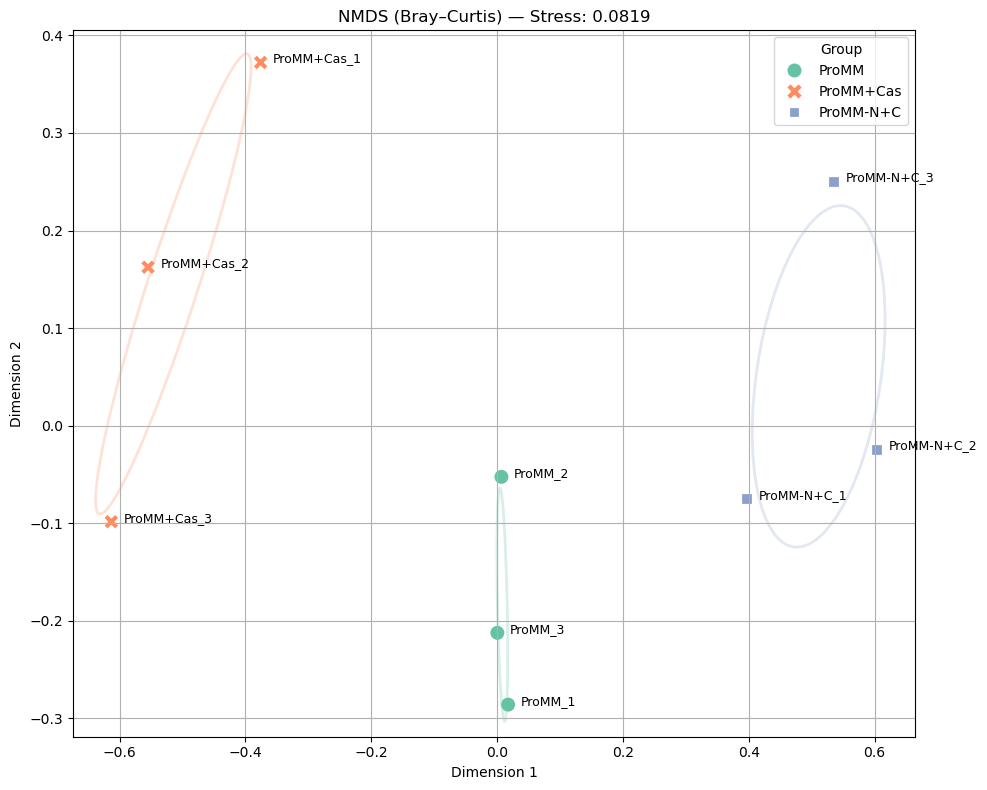


PERMANOVA Result:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                       9
number of groups                  3
test statistic            21.363247
p-value                       0.002
number of permutations          999
Name: PERMANOVA results, dtype: object

NMDS Stress: 0.0819


(       Dim1      Dim2       Sample      Group
 0  0.017425 -0.285799      ProMM_1      ProMM
 1  0.006814 -0.052377      ProMM_2      ProMM
 2  0.000317 -0.212240      ProMM_3      ProMM
 3 -0.375995  0.372285  ProMM+Cas_1  ProMM+Cas
 4 -0.554909  0.162459  ProMM+Cas_2  ProMM+Cas
 5 -0.613320 -0.098340  ProMM+Cas_3  ProMM+Cas
 6  0.395895 -0.074734  ProMM-N+C_1  ProMM-N+C
 7  0.603200 -0.024028  ProMM-N+C_2  ProMM-N+C
 8  0.534192  0.250518  ProMM-N+C_3  ProMM-N+C,
 np.float64(0.08186268959320493),
 method name               PERMANOVA
 test statistic name        pseudo-F
 sample size                       9
 number of groups                  3
 test statistic            21.363247
 p-value                       0.002
 number of permutations          999
 Name: PERMANOVA results, dtype: object)

In [18]:
chosen = ["ProMM", "ProMM-N+C", "ProMM+Cas"]
data_T, labels = data_mod(merged, chosen_suffixes=chosen)
NMDS(data_T, labels)

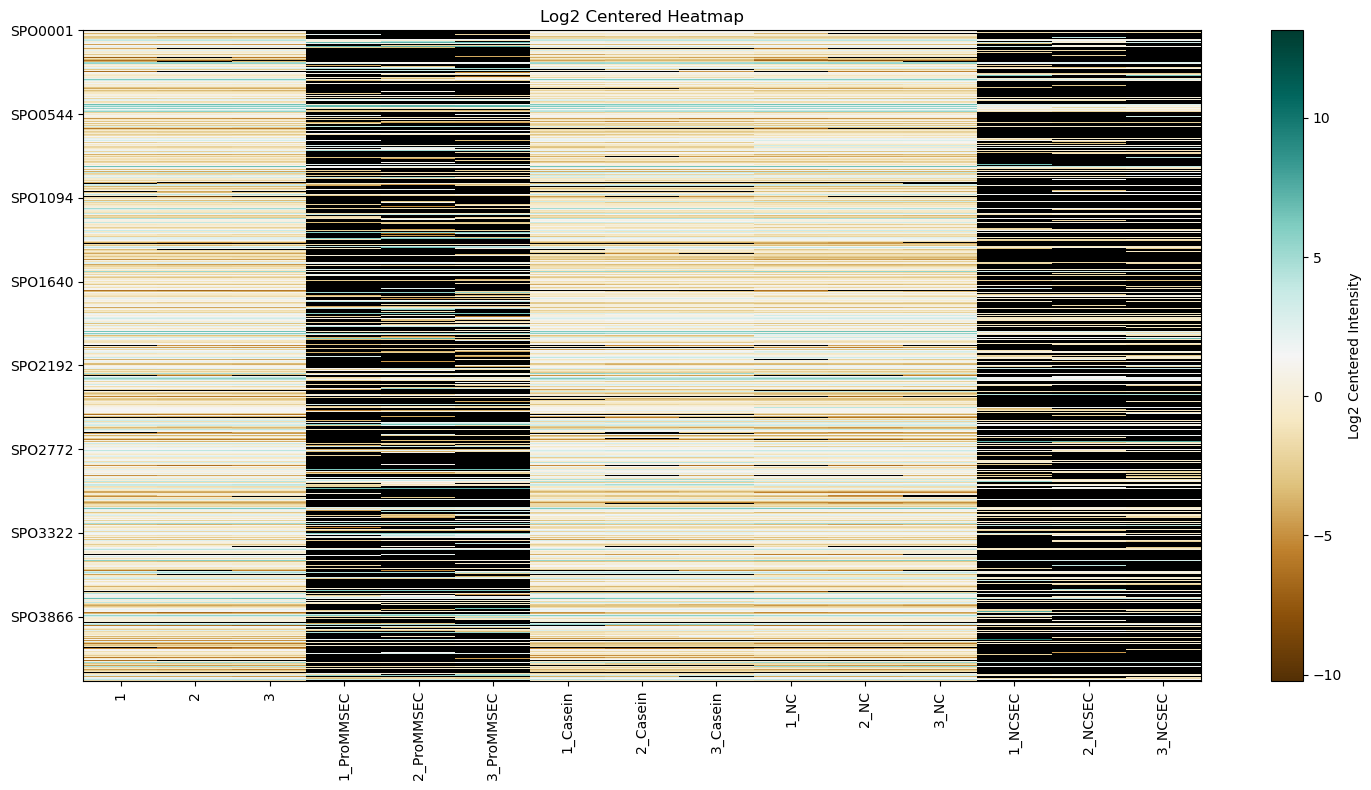

In [37]:
# Assuming 'filtered' contains your list of DataFrames (ProMM, ProMMSEC, Casein, NC, NCSEC)
dfs = [ProMM, ProMMSEC, Casein, NC, NCSEC]
suffixes = ['ProMM', 'ProMMSEC', 'Casein', 'NC', 'NCSEC']

# Start with the first DataFrame
merged = dfs[0]

# Merge the dataframes
for df, suffix in zip(dfs[1:], suffixes[1:]):
    merged = pd.merge(merged, df, on=['Accession Number', 'Annotation'], suffixes=('', f'_{suffix}'))
    merged = merged.sort_values(by='Accession Number')
    
# Drop the non-numeric columns
numeric_data = merged.drop(['Accession Number', 'Annotation'], axis=1)

# Log2 transform (preserving NaNs)
log2_data = np.log2(numeric_data)

# Subtract the median from each column
log2_data_centered = log2_data.sub(log2_data.median(axis=0), axis=1)

# Mask the NaNs
masked_data = np.ma.masked_invalid(log2_data_centered.values)

# Create colormap and set NaN color to gray
cmap = plt.cm.BrBG
cmap.set_bad(color='black')

# Plot using imshow instead of sns.heatmap
plt.figure(figsize=(15, 8))
im = plt.imshow(masked_data, aspect='auto', interpolation='none', cmap=cmap)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Log2 Centered Intensity')

# Optionally add axis ticks and labels
plt.xticks(ticks=np.arange(log2_data_centered.shape[1]), labels=log2_data_centered.columns, rotation=90)

# Set y-axis ticks to display every 500th Accession Number
yticks_indices = np.arange(0, log2_data_centered.shape[0], 500)  # Every 500th index
yticks_labels = merged['Accession Number'].iloc[yticks_indices]  # Corresponding Accession Numbers

# Set yticks to be every 500th Accession Number
plt.yticks(ticks=yticks_indices, labels=yticks_labels)

plt.title('Log2 Centered Heatmap')
plt.tight_layout()
#plt.savefig('GENERALS_heatmap.pdf', dpi=300)
plt.show()

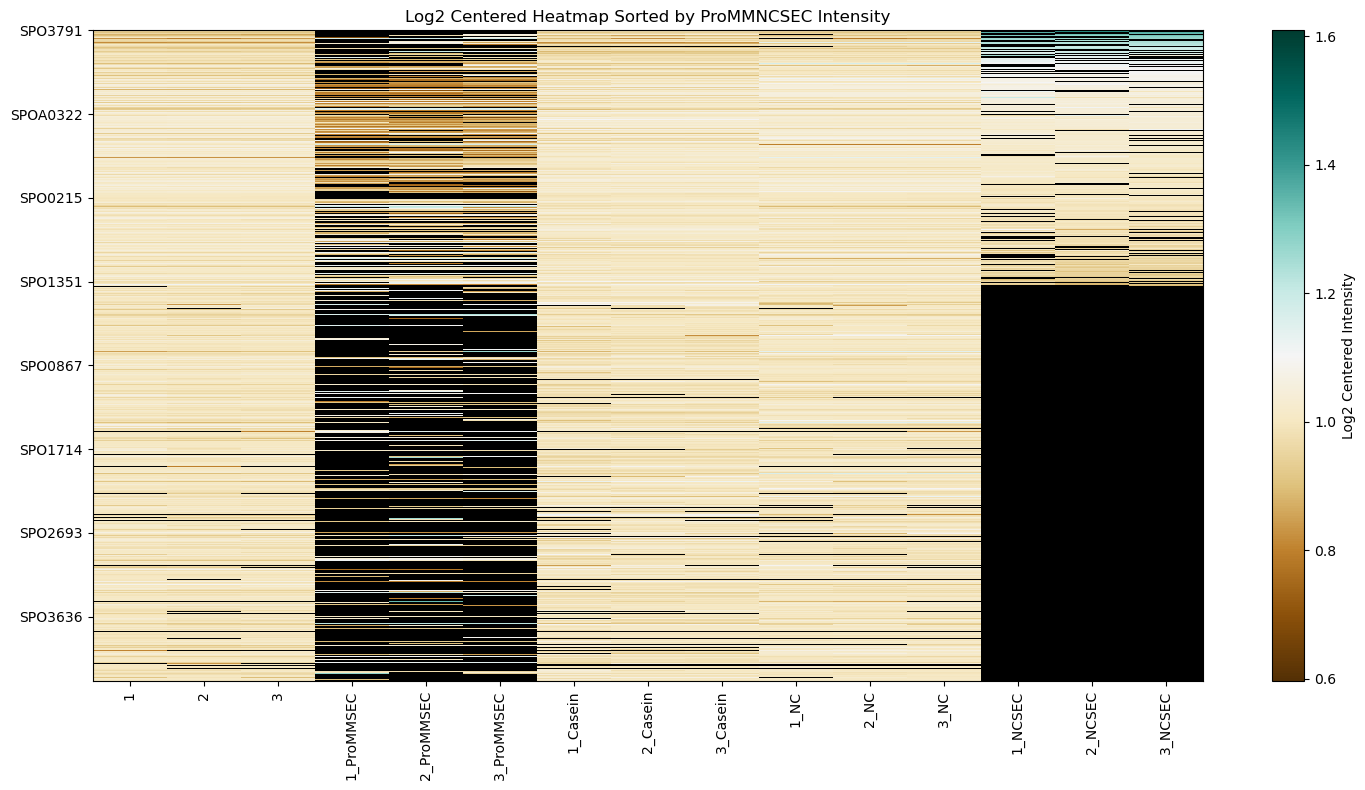

In [13]:
### Sort by Abundance in a certain condition, rather than sorting by accession number. 

dfs = [ProMM, ProMMSEC, Casein, NC, NCSEC]
suffixes = ['ProMM', 'ProMMSEC', 'Casein', 'NC', 'NCSEC']

# Start with the first DataFrame
merged = dfs[0]

# Merge the remaining DataFrames on ['Accession Number', 'Annotation']
for df, suffix in zip(dfs[1:], suffixes[1:]):
    merged = pd.merge(merged, df, on=['Accession Number', 'Annotation'], suffixes=('', f'_{suffix}'))
    merged = merged.sort_values(by='Accession Number')

# Drop non-numeric columns
numeric_data = merged.drop(['Accession Number', 'Annotation'], axis=1)

# Log2 transform (preserving NaNs)
log2_data = np.log2(numeric_data)

# Subtract the median from each column (log2 centered)
log2_data_centered = log2_data.sub(log2_data.median(axis=0), axis=1)

# Sort by ProMMSEC average intensity
NCSEC_cols = [col for col in log2_data_centered.columns if 'NCSEC' in col]

# Compute row-wise average log2 centered intensity for ProMMSEC
NCSEC_mean = log2_data_centered[NCSEC_cols].mean(axis=1)

# Sort both log2_data_centered and merged by this mean (descending)
sort_order = NCSEC_mean.sort_values(ascending=False).index
log2_data_centered_sorted = log2_data_centered.loc[sort_order]
merged_sorted = merged.loc[sort_order]

# Mask NaNs
masked_data = np.ma.masked_invalid(log2_data_centered_sorted.values)

# Create colormap and set NaN color to black
cmap = plt.cm.BrBG
cmap.set_bad(color='black')

# Plot heatmap using imshow
plt.figure(figsize=(15, 8))
im = plt.imshow(masked_data, aspect='auto', interpolation='none', cmap=cmap)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Log2 Centered Intensity')

# Set x-axis ticks and labels
plt.xticks(
    ticks=np.arange(log2_data_centered_sorted.shape[1]),
    labels=log2_data_centered_sorted.columns,
    rotation=90
)

# Set y-axis ticks every 500 proteins
yticks_indices = np.arange(0, log2_data_centered_sorted.shape[0], 500)
yticks_labels = merged_sorted['Accession Number'].iloc[yticks_indices]
plt.yticks(ticks=yticks_indices, labels=yticks_labels)

plt.title('Log2 Centered Heatmap Sorted by ProMMNCSEC Intensity')
plt.tight_layout()
#plt.savefig('GENERALS_heatmap_sortedby_ProMMNCSEC.pdf', dpi=300)
plt.show()


In [18]:
# Heatmap with Euclidean distance not just plotting normalized abundance. 

/Users/fadimestemmer/miniconda3/envs/MS_plot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/fadimestemmer/miniconda3/envs/MS_plot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


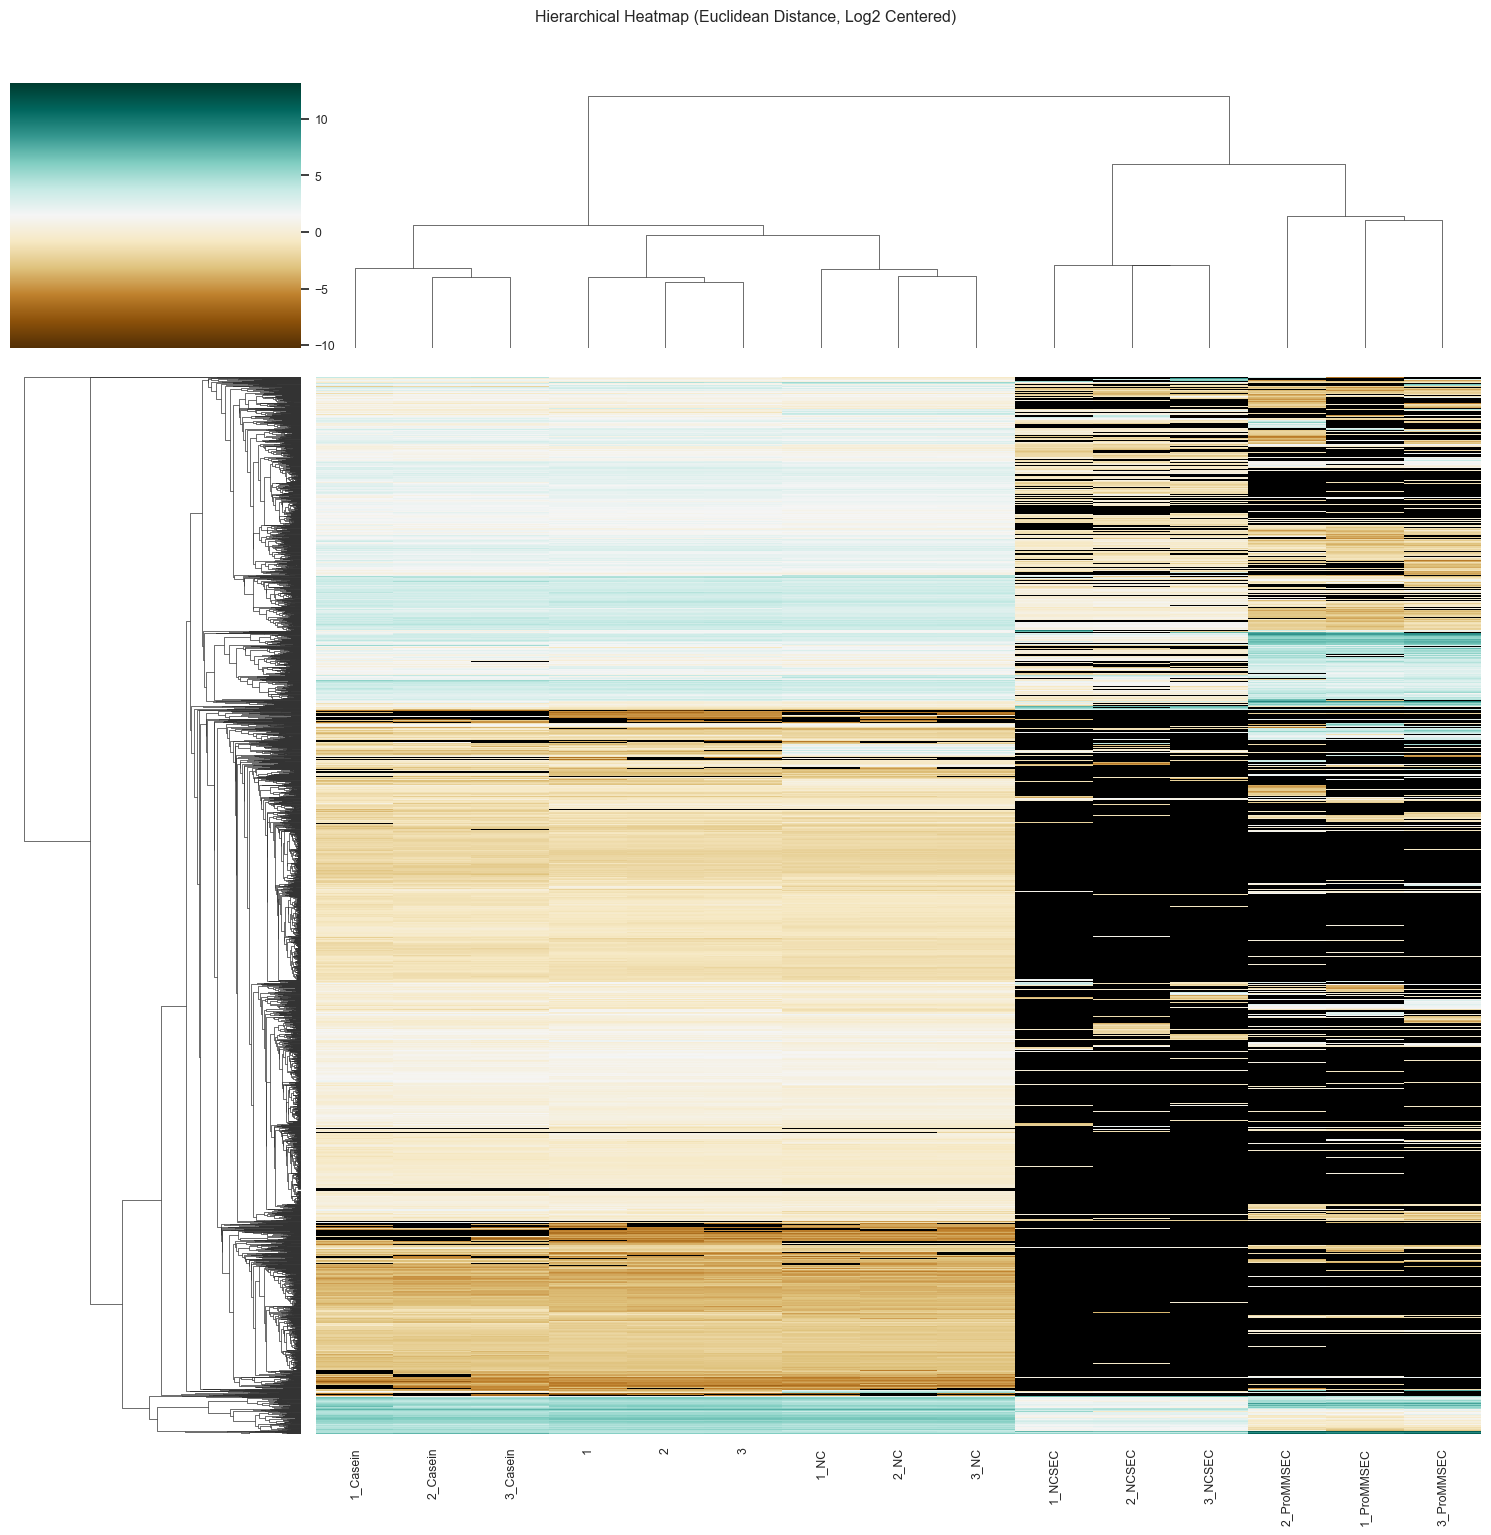

In [21]:
# Merge all dataframes
dfs = [ProMM, ProMMSEC, Casein, NC, NCSEC]
suffixes = ['ProMM', 'ProMMSEC', 'Casein', 'NC', 'NCSEC']

merged = dfs[0]
for df, suffix in zip(dfs[1:], suffixes[1:]):
    merged = pd.merge(merged, df, on=['Accession Number', 'Annotation'], suffixes=('', f'_{suffix}'))
    merged = merged.sort_values(by='Accession Number')

# Drop non-numeric columns
numeric_data = merged.drop(['Accession Number', 'Annotation'], axis=1)

# Log2 transform
log2_data = np.log2(numeric_data)

# Median centering
log2_data_centered = log2_data.sub(log2_data.median(axis=0), axis=1)

# Sort rows by average NCSEC intensity
NCSEC_cols = [col for col in log2_data_centered.columns if 'NCSEC' in col]
NCSEC_mean = log2_data_centered[NCSEC_cols].mean(axis=1)
sort_order = NCSEC_mean.sort_values(ascending=False).index

# Sort data
log2_data_centered_sorted = log2_data_centered.loc[sort_order]
row_labels = merged.loc[sort_order, 'Accession Number']
cleaned_data = log2_data_centered_sorted.fillna(0)


# Set up colormap with black for NaNs
cmap = plt.cm.BrBG
cmap.set_bad(color='black')

# Create a seaborn clustermap with Euclidean distance
sns.set(font_scale=0.8)
g = sns.clustermap(
    cleaned_data,
    metric='euclidean',
    method='average',  
    cmap=cmap,
    figsize=(15, 15),
    xticklabels=True,
    yticklabels=False, 
    mask=log2_data_centered_sorted.isna()
)

plt.suptitle('Hierarchical Heatmap (Euclidean Distance, Log2 Centered)', y=1.02)
plt.savefig('GENERALS_heatmap_corr.pdf', dpi=300)
plt.tight_layout()
plt.show()

In [6]:
# Load data
ProMM = pd.read_csv('../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM_ML_annotated.txt', delimiter='\t')
ProMMSEC = pd.read_csv('../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM_MLSec_annotated.txt', delimiter='\t')
Casein = pd.read_csv('../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM+Cas_ML_annotated.txt', delimiter='\t') 
NC = pd.read_csv('../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM-N+C_ML_annotated.txt', delimiter='\t')
NCSEC = pd.read_csv('../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM-N+C_MLsec_annotated.txt', delimiter='\t')

# Filter function
def filter_by_keywords(df, keywords):
    pattern = '|'.join(keywords)
    return df[df['Annotation'].str.contains(pattern, case=False, na=False)]

# Apply to data 
# Proteases & Peptidases
ProMM_Protease = filter_by_keywords(ProMM, ['protease', 'peptidase'])
ProMMSEC_Protease = filter_by_keywords(ProMMSEC, ['protease', 'peptidase'])
Casein_Protease = filter_by_keywords(Casein, ['protease', 'peptidase'])
NC_Protease = filter_by_keywords(NC, ['protease', 'peptidase'])
NCSEC_Protease = filter_by_keywords(NCSEC, ['protease', 'peptidase'])

#Transporters
ProMM_Transporter = filter_by_keywords(ProMM, ['transport'])
ProMMSEC_Transporter = filter_by_keywords(ProMMSEC, ['transport'])
Casein_Transporter = filter_by_keywords(Casein, ['transport'])
NC_Transporter = filter_by_keywords(NC, ['transport'])
NCSEC_Transporter = filter_by_keywords(NCSEC, ['transport'])

#SBPs
ProMM_SBP = filter_by_keywords(ProMM, ['solute'])
ProMMSEC_SBP = filter_by_keywords(ProMMSEC, ['solute'])
Casein_SBP = filter_by_keywords(Casein, ['solute'])
NC_SBP = filter_by_keywords(NC, ['solute'])
NCSEC_SBP = filter_by_keywords(NCSEC, ['solute'])

# Amino Acid
ProMM_AA = filter_by_keywords(ProMM, ['amino acid'])
ProMMSEC_AA = filter_by_keywords(ProMMSEC, ['amino acid'])
Casein_AA = filter_by_keywords(Casein, ['amino acid'])
NC_AA = filter_by_keywords(NC, ['amino acid'])
NCSEC_AA = filter_by_keywords(NCSEC, ['amino acid'])

# Secretion
ProMM_sec = filter_by_keywords(ProMM, ['secretion'])
ProMMSEC_sec = filter_by_keywords(ProMMSEC, ['secretion'])
Casein_sec = filter_by_keywords(Casein, ['secretion'])
NC_sec = filter_by_keywords(NC, ['secretion'])
NCSEC_sec = filter_by_keywords(NCSEC, ['secretion'])

#Spermidine/putrescine transport
ProMM_sp = filter_by_keywords(ProMM, ['spermidine'])
ProMMSEC_sp = filter_by_keywords(ProMMSEC, ['spermidine'])
Casein_sp = filter_by_keywords(Casein, ['spermidine'])
NC_sp = filter_by_keywords(NC, ['spermidine'])
NCSEC_sp = filter_by_keywords(NCSEC, ['spermidine'])

# Decarboxylase
ProMM_decarb = filter_by_keywords(ProMM, ['decarboxylase'])
ProMMSEC_decarb = filter_by_keywords(ProMMSEC, ['decarboxylase'])
Casein_decarb = filter_by_keywords(Casein, ['decarboxylase'])
NC_decarb = filter_by_keywords(NC, ['decarboxylase'])
NCSEC_decarb = filter_by_keywords(NCSEC, ['decarboxylase'])


#Create Lists of functionalities
#PPT = [ProMM_PPT, ProMMSEC_PPT, Casein_PPT, NC_PPT, NCSEC_PPT]
Protease = [ProMM_Protease, ProMMSEC_Protease, Casein_Protease, NC_Protease, NCSEC_Protease]
Transporter = [ProMM_Transporter, ProMMSEC_Transporter, Casein_Transporter, NC_Transporter, NCSEC_Transporter]
SBP = [ProMM_SBP, ProMMSEC_SBP, Casein_SBP, NC_SBP, NCSEC_SBP]
AA = [ProMM_AA, ProMMSEC_AA, Casein_AA, NC_AA, NCSEC_AA]
secretion = [ProMM_sec, ProMMSEC_sec, Casein_sec, NC_sec, NCSEC_sec]
spermidine = [ProMM_sp, ProMMSEC_sp, Casein_sp, NC_sp, NCSEC_sp]
decarb = [ProMM_decarb, ProMMSEC_decarb, Casein_decarb, NC_decarb, NCSEC_decarb]
suffixes = ['ProMM', 'ProMMSEC', 'Casein', 'NC', 'NCSEC']

# Heatmap Function
def heatmap(dfs, suffixes, output_filename=''):
    # Start with first DataFrame
    merged = dfs[0]

    # Merge rest on ['Accession Number', 'Annotation']
    for df, suffix in zip(dfs[1:], suffixes[1:]):
        merged = pd.merge(merged, df, on=['Accession Number', 'Annotation'], suffixes=('', f'_{suffix}'))
        merged = merged.sort_values(by='Accession Number')

    # Drop non-numeric
    numeric_data = merged.drop(['Accession Number', 'Annotation'], axis=1)

    # Log2 transform (preserve NaNs)
    log2_data = np.log2(numeric_data)

    # Center by median
    log2_data_centered = log2_data.sub(log2_data.median(axis=0), axis=1)

    # Sort by NCSEC average intensity
    NCSEC_cols = [col for col in log2_data_centered.columns if 'NCSEC' in col]
    NCSEC_mean = log2_data_centered[NCSEC_cols].mean(axis=1)
    sort_order = NCSEC_mean.sort_values(ascending=False).index
    log2_data_centered_sorted = log2_data_centered.loc[sort_order]
    merged_sorted = merged.loc[sort_order]

    # Mask NaNs
    masked_data = np.ma.masked_invalid(log2_data_centered_sorted.values)

    # Create heatmap
    cmap = plt.cm.BrBG
    cmap.set_bad(color='black')

    plt.figure(figsize=(15, 15))
    im = plt.imshow(masked_data, aspect='auto', interpolation='none', cmap=cmap)

    # Colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('Log2 Centered Intensity')

    # X-axis labels
    plt.xticks(
        ticks=np.arange(log2_data_centered_sorted.shape[1]),
        labels=log2_data_centered_sorted.columns,
        rotation=90
    )

    # Y-axis labels
    yticks_indices = np.arange(0, log2_data_centered_sorted.shape[0], 1)
    yticks_labels = merged_sorted['Accession Number'].iloc[yticks_indices]
    plt.yticks(ticks=yticks_indices, labels=yticks_labels)

    plt.title(f'Log2 Centered Heatmap')
    plt.tight_layout()
    
    #if output_filename:
     #   plt.savefig(f'../../../GENERALS FIGURES/{output_filename}.pdf',format='pdf', dpi=300)
    
    plt.show()

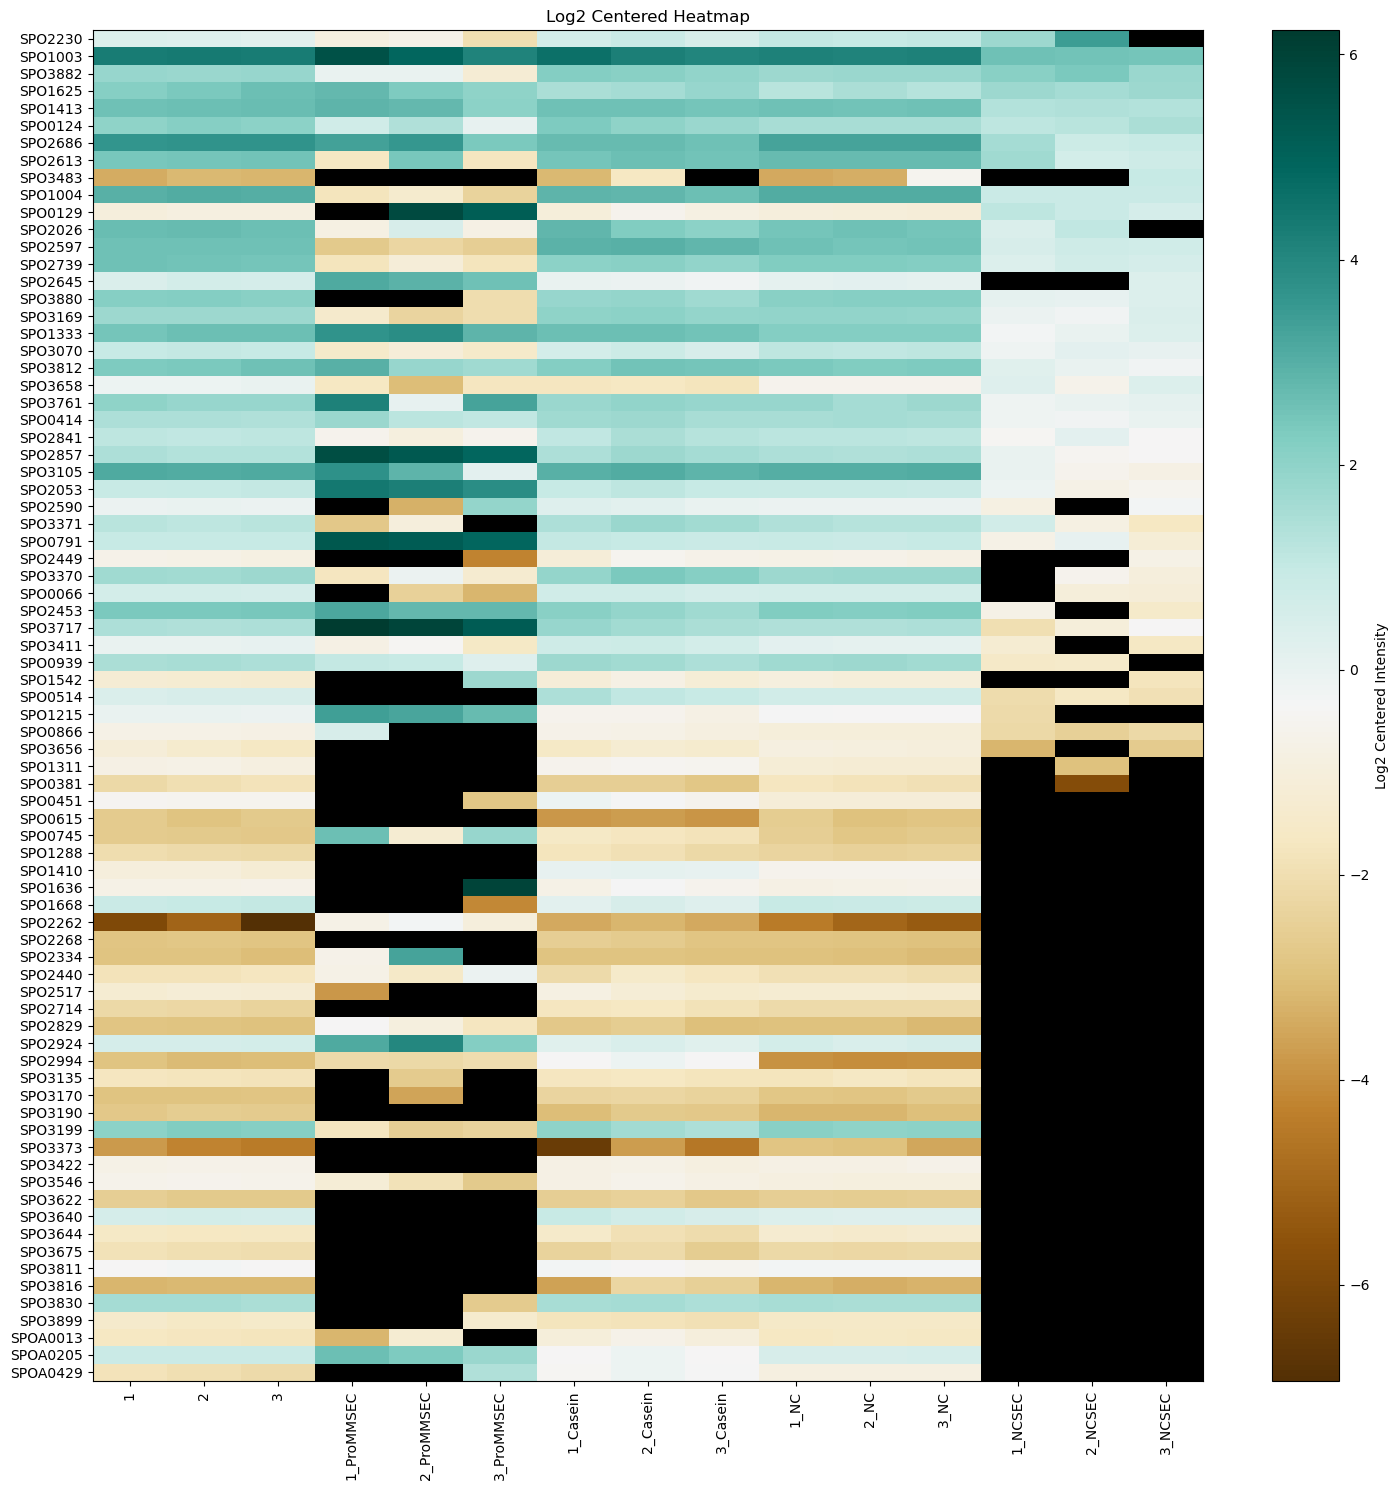

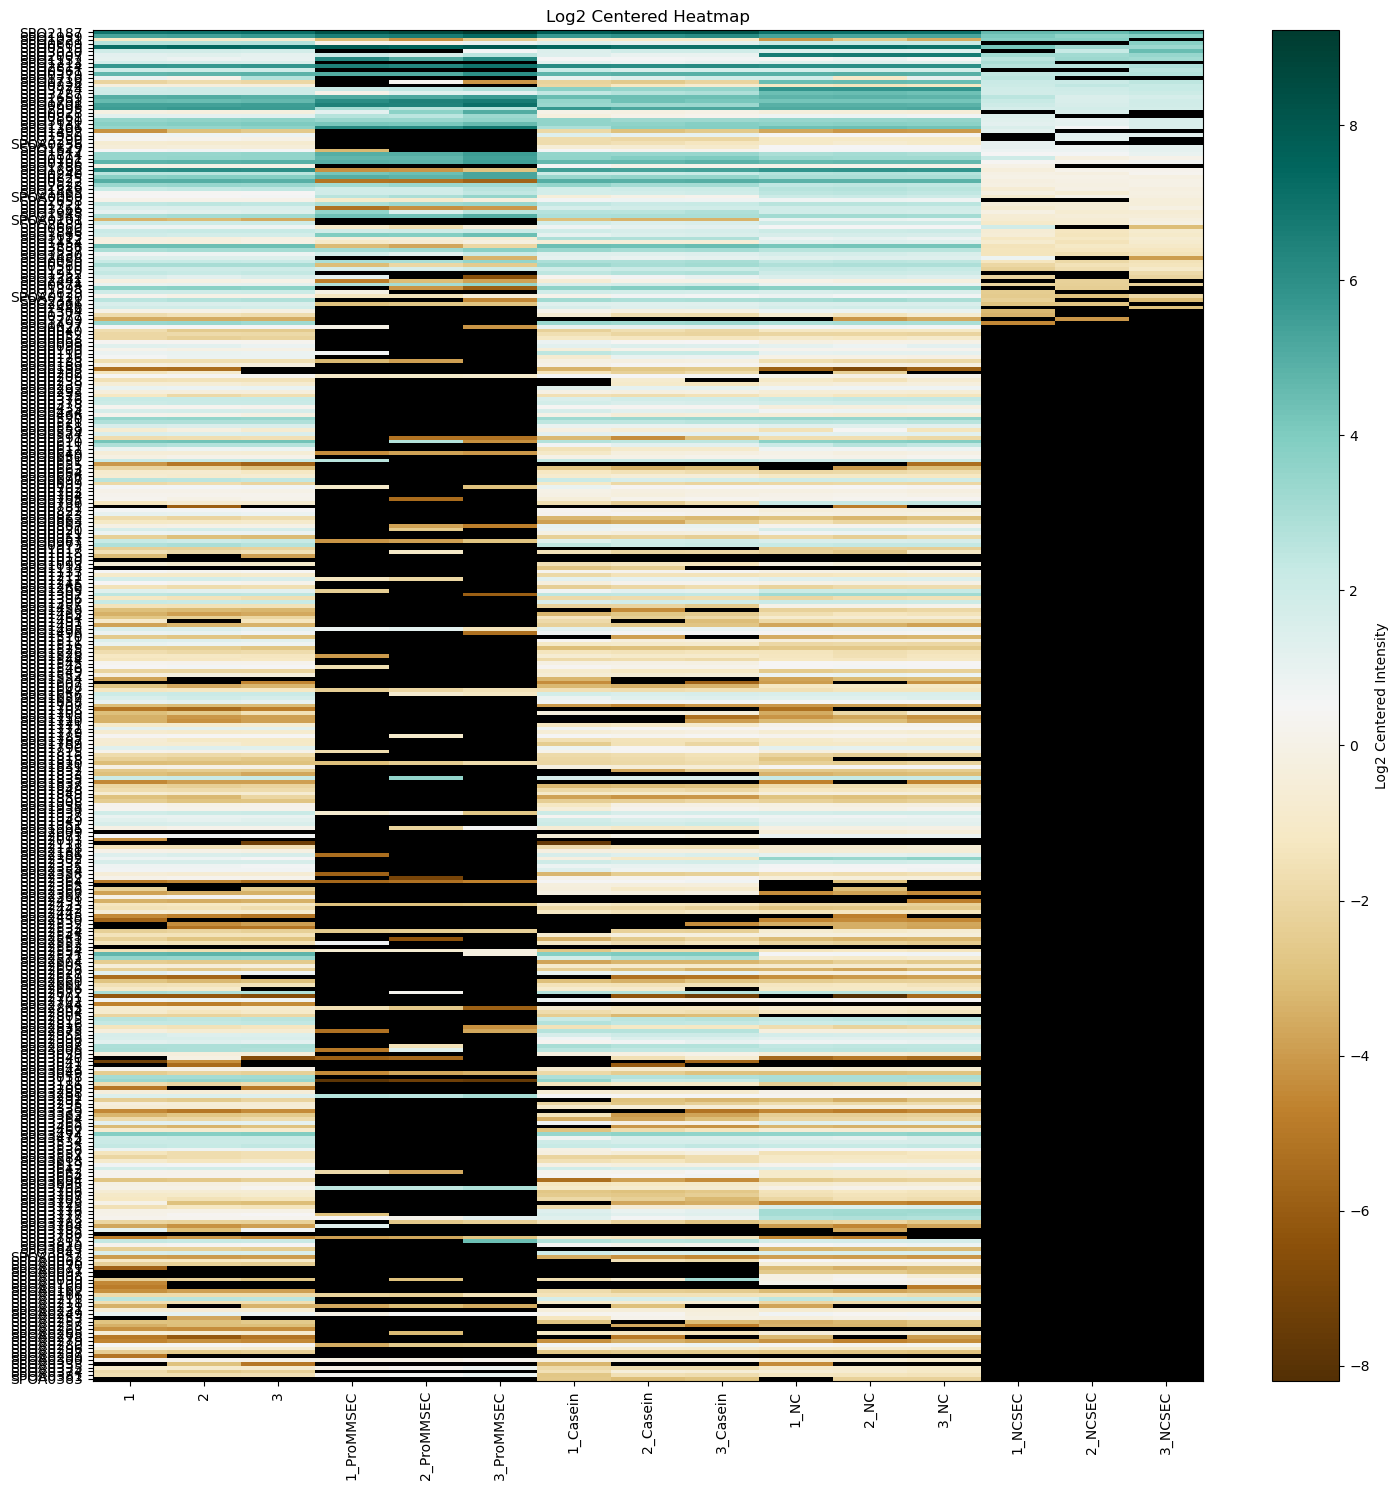

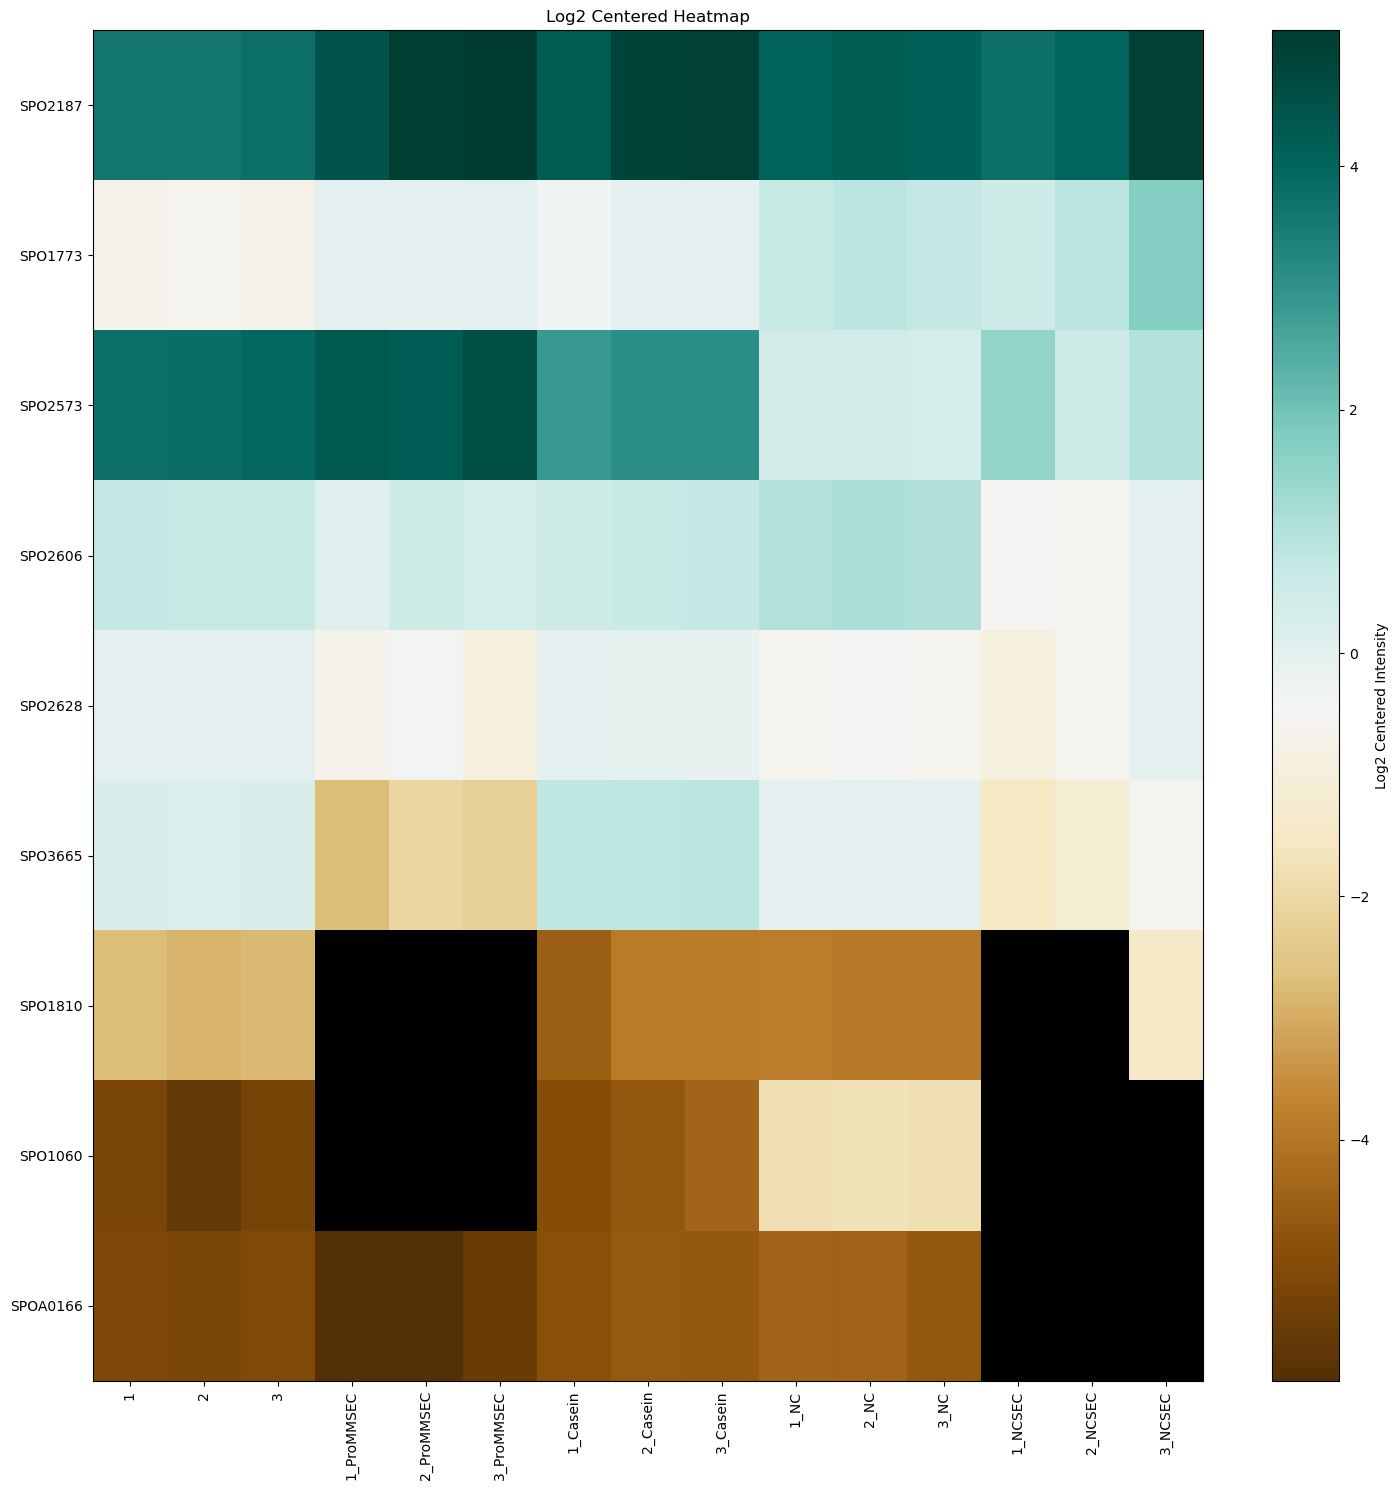

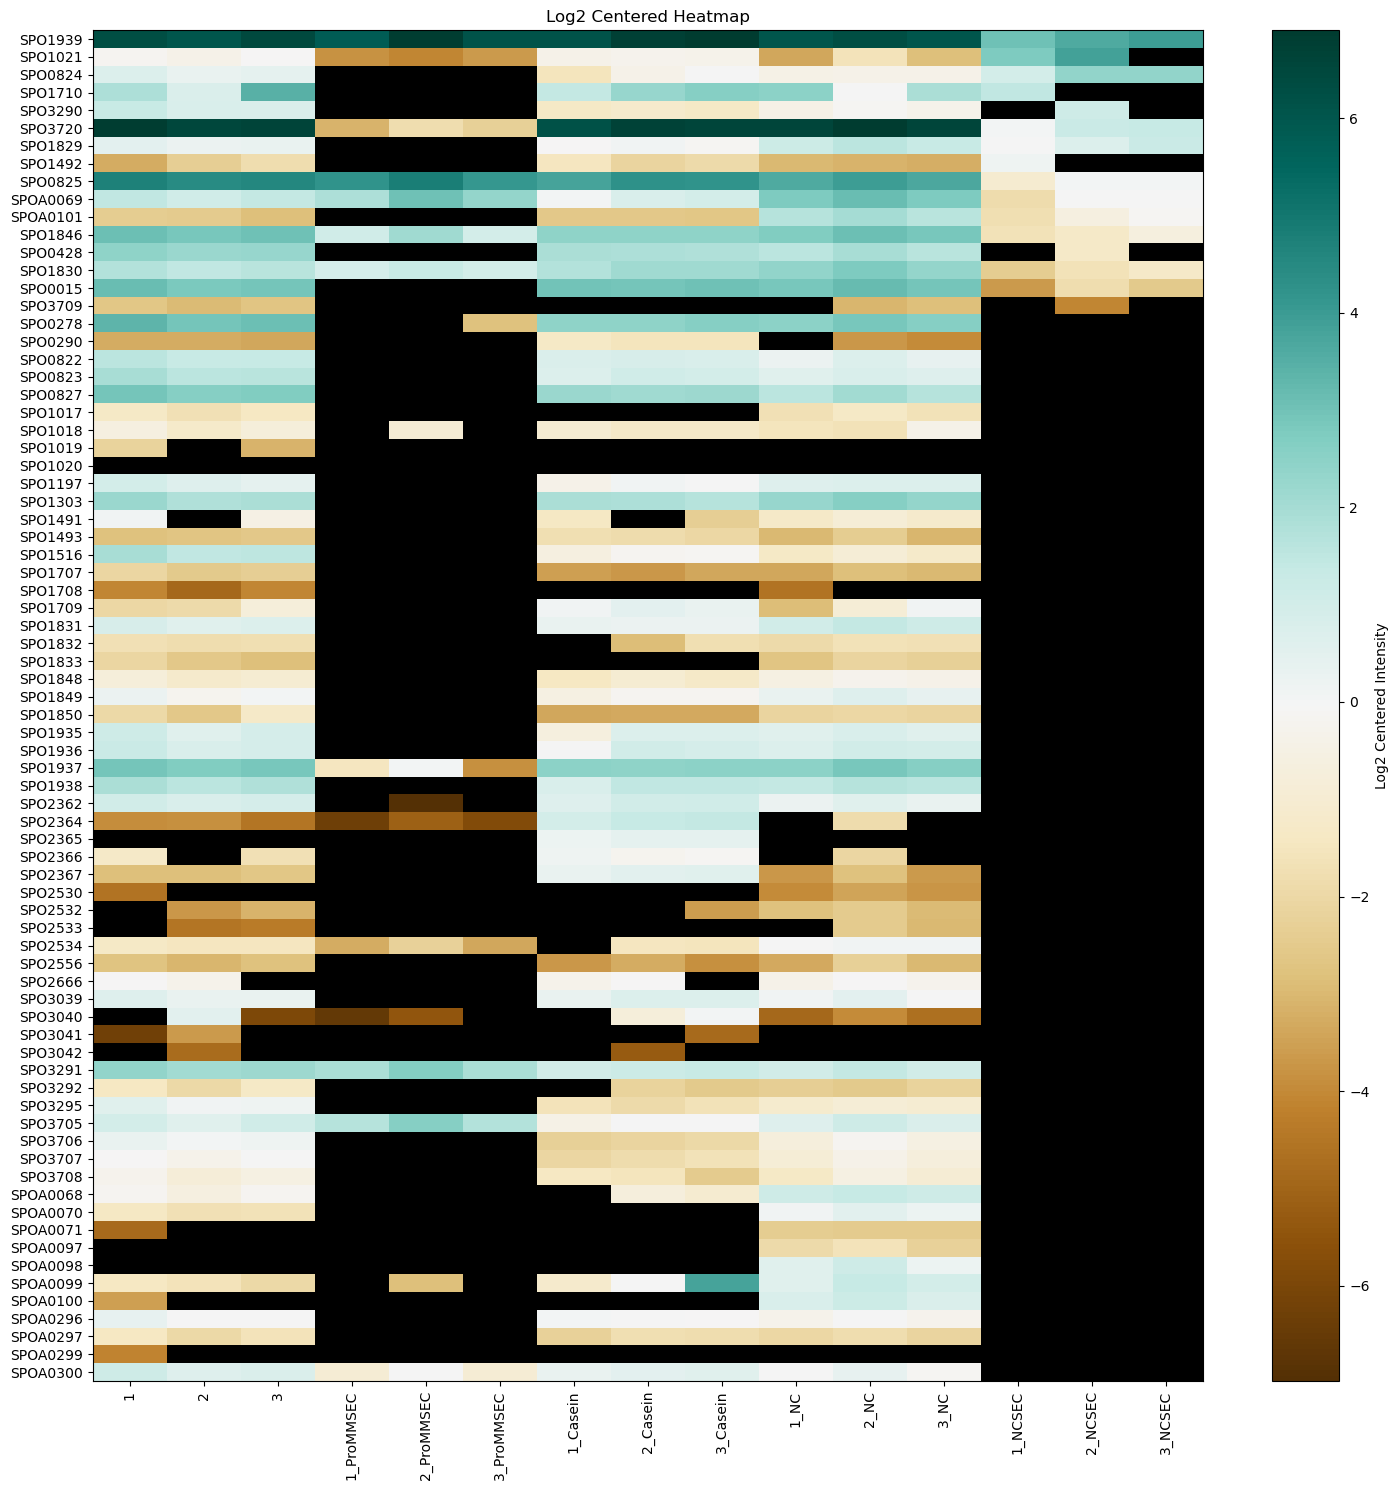

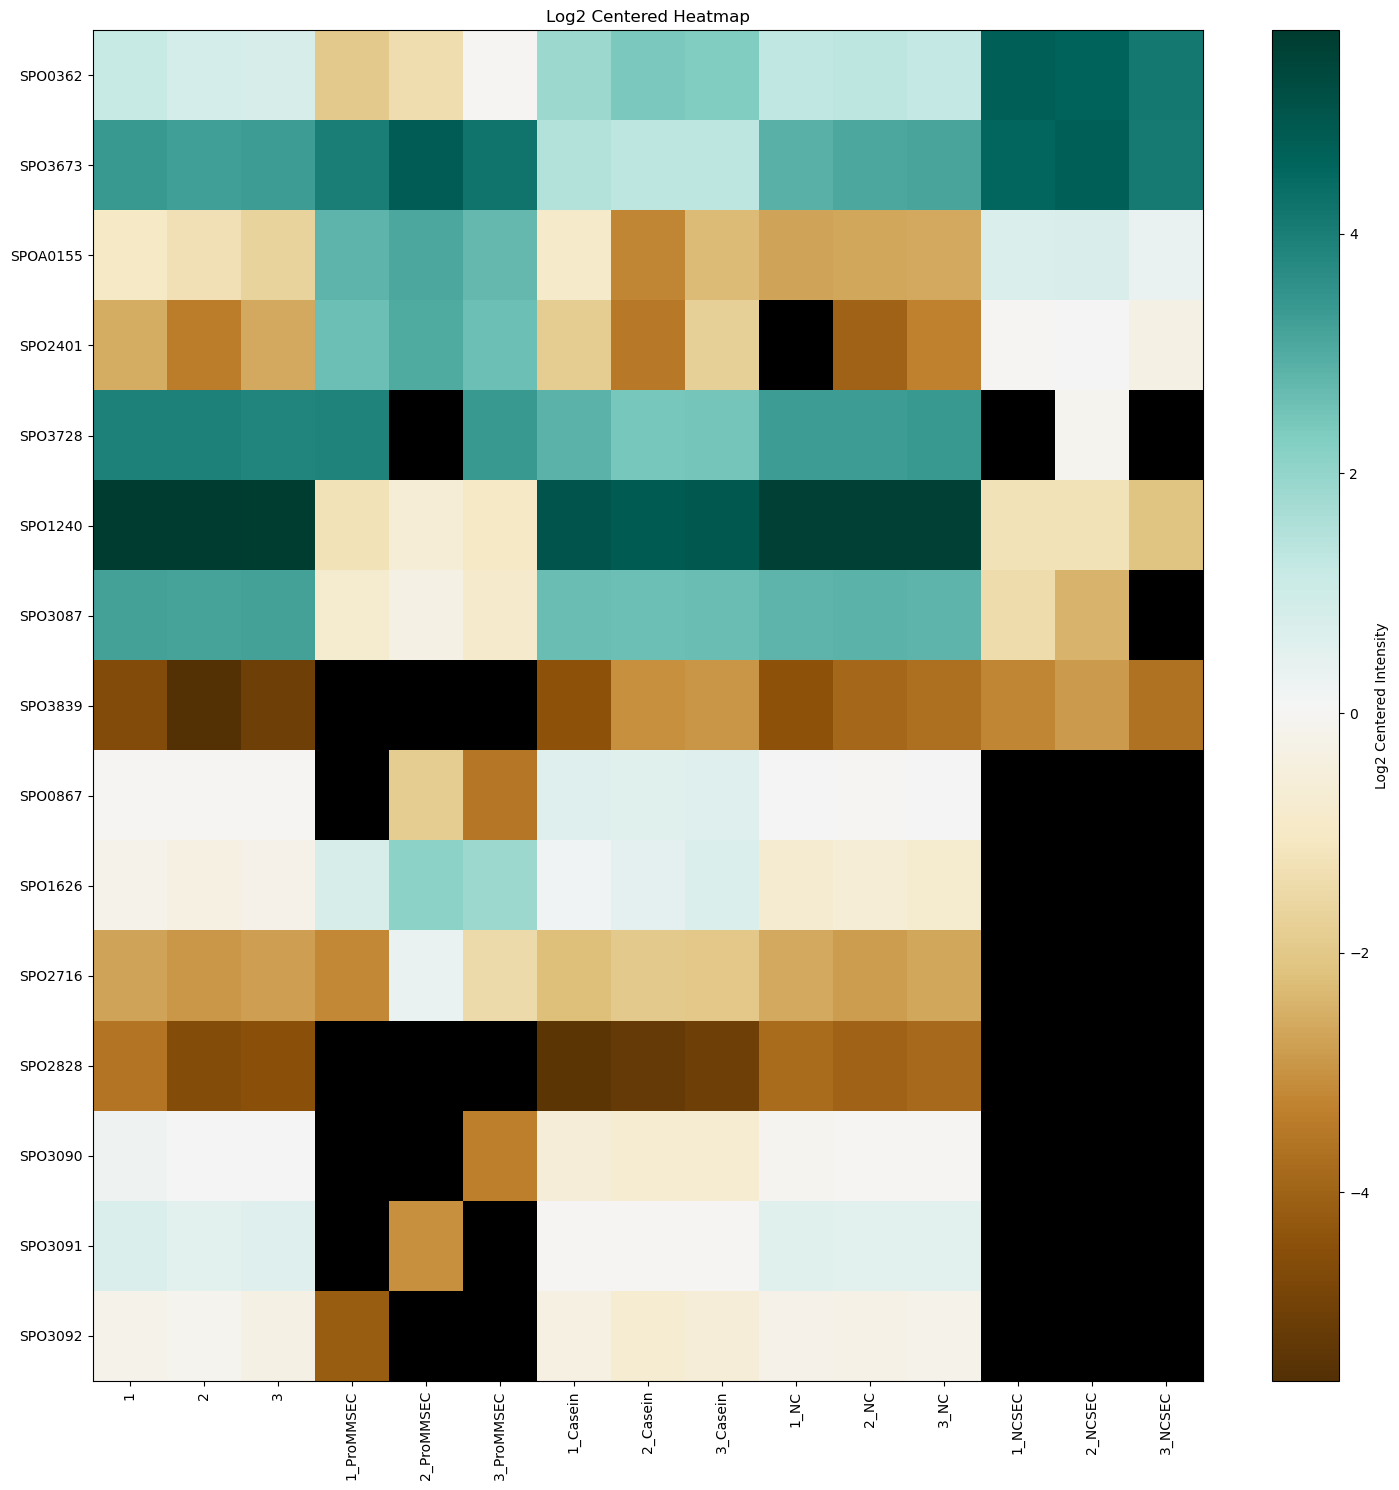

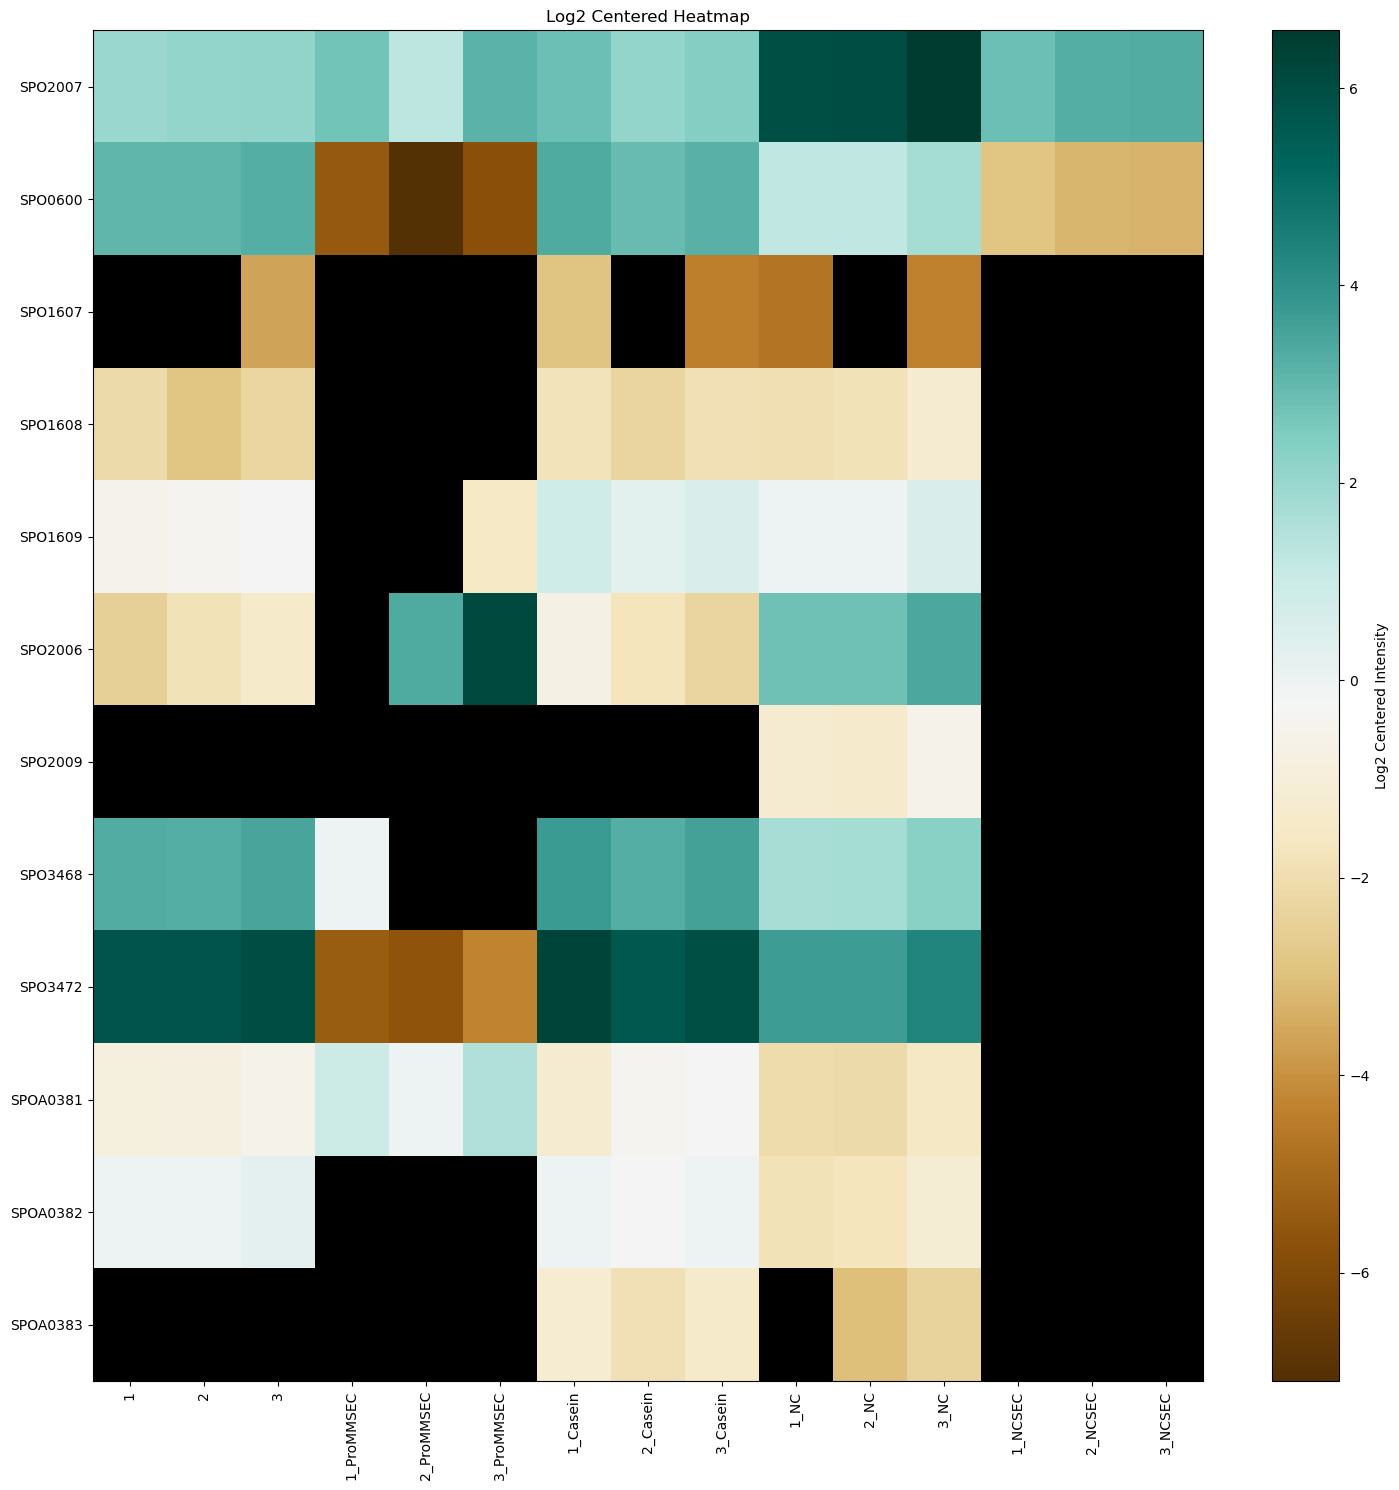

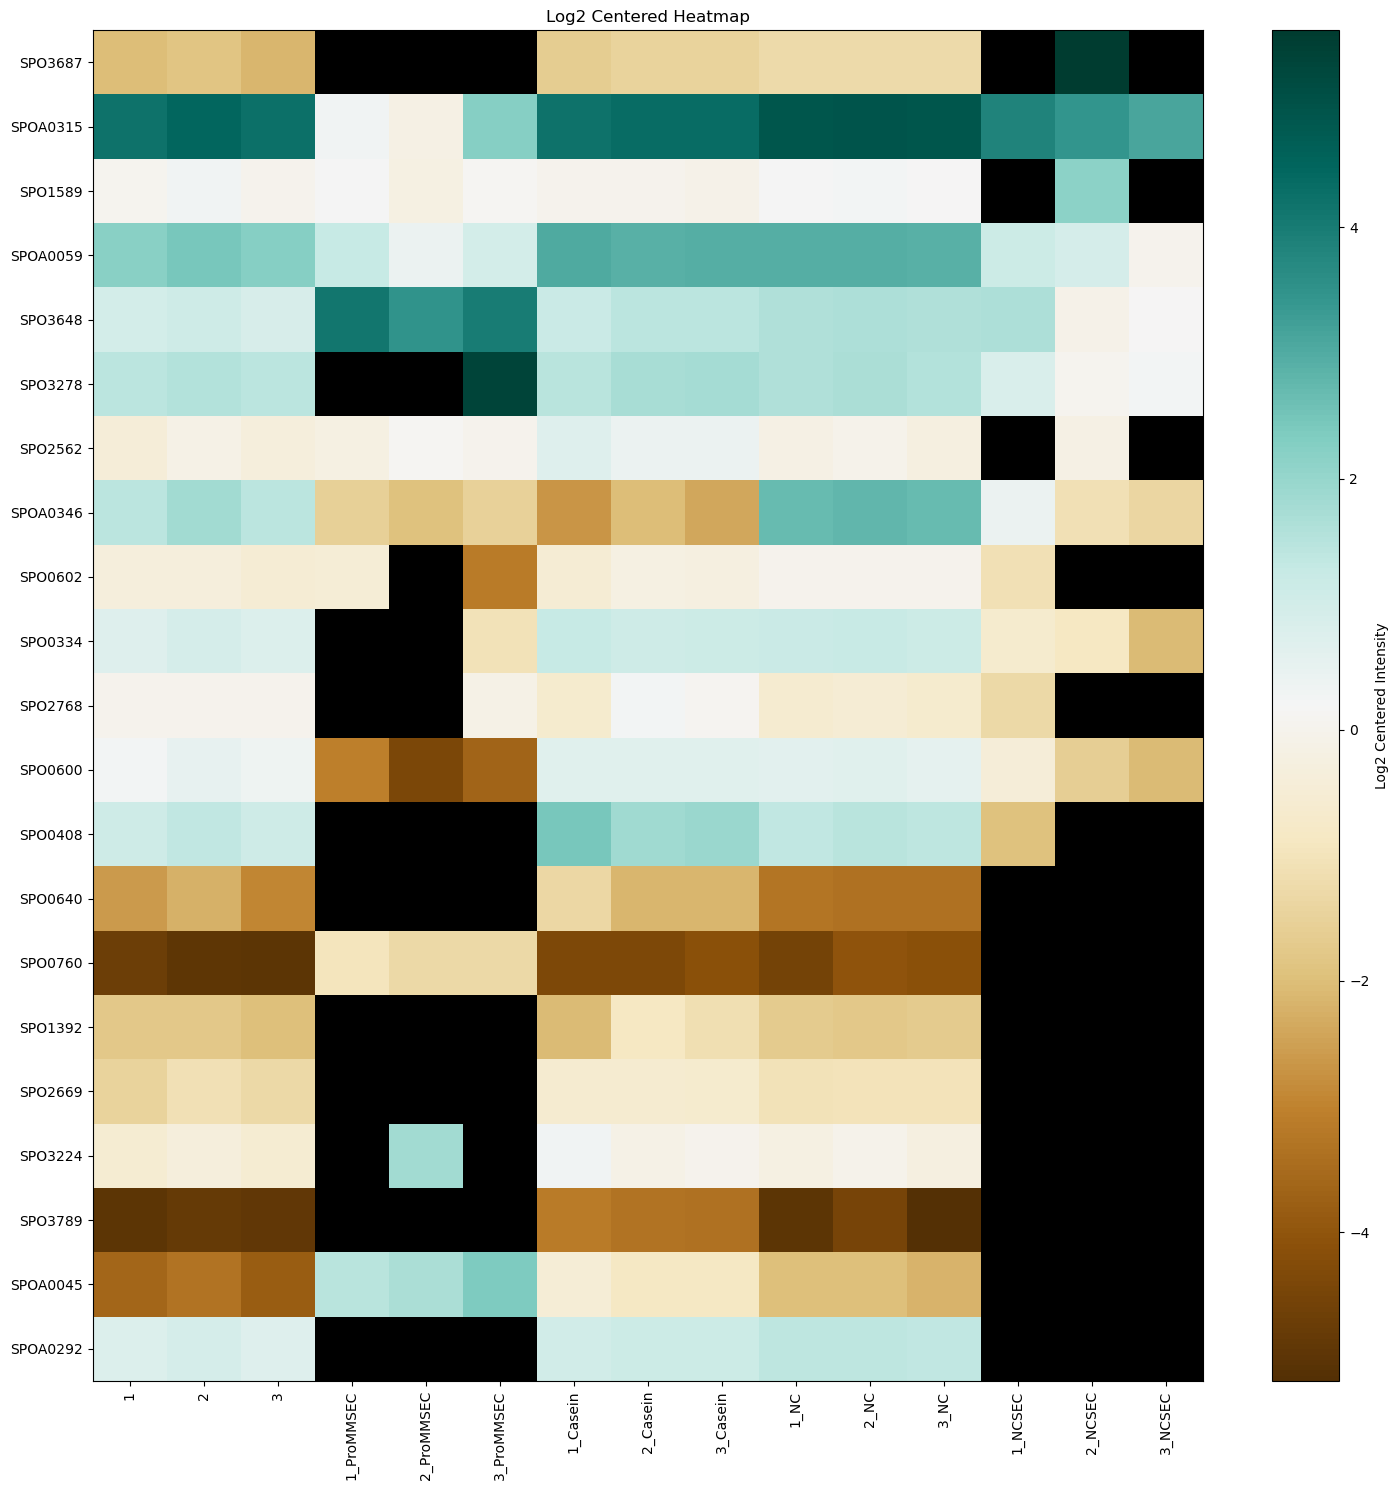

In [7]:
heatmap(Protease, suffixes, output_filename='heatmap_protease')
heatmap(Transporter, suffixes, output_filename='heatmap_transporter')
heatmap(SBP, suffixes, output_filename='heatmap_SBP')
heatmap(AA, suffixes, output_filename='heatmap_aminoacid')
heatmap(secretion, suffixes, output_filename='heatmap_secretionproteins')
heatmap(spermidine, suffixes, output_filename='heatmap_spermidine')
heatmap(decarb, suffixes, output_filename='heatmap_decarboxylase')

In [9]:
# Load data
ProMM = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM_ML_annotated.txt', delimiter='\t')
ProMMSEC = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM_MLSec_annotated.txt', delimiter='\t')
Casein = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM+Cas_ML_annotated.txt', delimiter='\t') 
NC = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM-N+C_ML_annotated.txt', delimiter='\t')
NCSEC = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM-N+C_MLsec_annotated.txt', delimiter='\t')

# Filter function
def filter_by_keywords(df, keywords):
    pattern = '|'.join(keywords)
    return df[df['Annotation'].str.contains(pattern, case=False, na=False)]

# Apply to data 
# Proteases & Peptidases
ProMM_Protease = filter_by_keywords(ProMM, ['protease', 'peptidase'])
ProMMSEC_Protease = filter_by_keywords(ProMMSEC, ['protease', 'peptidase'])
Casein_Protease = filter_by_keywords(Casein, ['protease', 'peptidase'])
NC_Protease = filter_by_keywords(NC, ['protease', 'peptidase'])
NCSEC_Protease = filter_by_keywords(NCSEC, ['protease', 'peptidase'])

#Transporters
ProMM_Transporter = filter_by_keywords(ProMM, ['transport'])
ProMMSEC_Transporter = filter_by_keywords(ProMMSEC, ['transport'])
Casein_Transporter = filter_by_keywords(Casein, ['transport'])
NC_Transporter = filter_by_keywords(NC, ['transport'])
NCSEC_Transporter = filter_by_keywords(NCSEC, ['transport'])

#SBPs
ProMM_SBP = filter_by_keywords(ProMM, ['solute'])
ProMMSEC_SBP = filter_by_keywords(ProMMSEC, ['solute'])
Casein_SBP = filter_by_keywords(Casein, ['solute'])
NC_SBP = filter_by_keywords(NC, ['solute'])
NCSEC_SBP = filter_by_keywords(NCSEC, ['solute'])

# Amino Acid
ProMM_AA = filter_by_keywords(ProMM, ['amino acid'])
ProMMSEC_AA = filter_by_keywords(ProMMSEC, ['amino acid'])
Casein_AA = filter_by_keywords(Casein, ['amino acid'])
NC_AA = filter_by_keywords(NC, ['amino acid'])
NCSEC_AA = filter_by_keywords(NCSEC, ['amino acid'])

# Secretion
ProMM_sec = filter_by_keywords(ProMM, ['secretion'])
ProMMSEC_sec = filter_by_keywords(ProMMSEC, ['secretion'])
Casein_sec = filter_by_keywords(Casein, ['secretion'])
NC_sec = filter_by_keywords(NC, ['secretion'])
NCSEC_sec = filter_by_keywords(NCSEC, ['secretion'])

#Spermidine/putrescine transport
ProMM_sp = filter_by_keywords(ProMM, ['spermidine'])
ProMMSEC_sp = filter_by_keywords(ProMMSEC, ['spermidine'])
Casein_sp = filter_by_keywords(Casein, ['spermidine'])
NC_sp = filter_by_keywords(NC, ['spermidine'])
NCSEC_sp = filter_by_keywords(NCSEC, ['spermidine'])

# Decarboxylase
ProMM_decarb = filter_by_keywords(ProMM, ['decarboxylase'])
ProMMSEC_decarb = filter_by_keywords(ProMMSEC, ['decarboxylase'])
Casein_decarb = filter_by_keywords(Casein, ['decarboxylase'])
NC_decarb = filter_by_keywords(NC, ['decarboxylase'])
NCSEC_decarb = filter_by_keywords(NCSEC, ['decarboxylase'])


#Create Lists of functionalities
#PPT = [ProMM_PPT, ProMMSEC_PPT, Casein_PPT, NC_PPT, NCSEC_PPT]
Protease = [ProMM_Protease, ProMMSEC_Protease, Casein_Protease, NC_Protease, NCSEC_Protease]
Transporter = [ProMM_Transporter, ProMMSEC_Transporter, Casein_Transporter, NC_Transporter, NCSEC_Transporter]
SBP = [ProMM_SBP, ProMMSEC_SBP, Casein_SBP, NC_SBP, NCSEC_SBP]
AA = [ProMM_AA, ProMMSEC_AA, Casein_AA, NC_AA, NCSEC_AA]
secretion = [ProMM_sec, ProMMSEC_sec, Casein_sec, NC_sec, NCSEC_sec]
spermidine = [ProMM_sp, ProMMSEC_sp, Casein_sp, NC_sp, NCSEC_sp]
decarb = [ProMM_decarb, ProMMSEC_decarb, Casein_decarb, NC_decarb, NCSEC_decarb]
suffixes = ['ProMM', 'ProMMSEC', 'Casein', 'NC', 'NCSEC']

# Heatmap Function
def heatmap(dfs, suffixes, output_filename=''):
    # Start with first DataFrame
    merged = dfs[0]

    # Merge rest on ['Accession Number', 'Annotation']
    for df, suffix in zip(dfs[1:], suffixes[1:]):
        merged = pd.merge(merged, df, on=['Accession Number', 'Annotation'], suffixes=('', f'_{suffix}'))
        merged = merged.sort_values(by='Accession Number')

    # Drop non-numeric
    numeric_data = merged.drop(['Accession Number', 'Annotation'], axis=1)

    # Log2 transform (preserve NaNs)
    log2_data = np.log2(numeric_data)
    print(log2_data)

    # Row-wise normalization by row mean
    #row_mean = log2_data.mean(axis=1)
    #log2_data_centered = log2_data.div(row_mean, axis=0)

    # Row-wise normalization by row max
    row_max = log2_data.max(axis=1)
    log2_data_centered = log2_data.div(row_max, axis=0)

    # Sort by NCSEC average intensity
    NCSEC_cols = [col for col in log2_data_centered.columns if 'NCSEC' in col]
    NCSEC_mean = log2_data_centered[NCSEC_cols].mean(axis=1)
    sort_order = NCSEC_mean.sort_values(ascending=False).index
    log2_data_centered_sorted = log2_data_centered.loc[sort_order]
    merged_sorted = merged.loc[sort_order]

    # Mask NaNs
    masked_data = np.ma.masked_invalid(log2_data_centered_sorted.values)

    # Create heatmap
    cmap = plt.cm.BrBG
    cmap.set_bad(color='black')

    plt.figure(figsize=(15, 15))
    im = plt.imshow(masked_data, aspect='auto', interpolation='none', cmap=cmap)

    # Colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('Log2 Centered Intensity')

    # X-axis labels
    plt.xticks(
        ticks=np.arange(log2_data_centered_sorted.shape[1]),
        labels=log2_data_centered_sorted.columns,
        rotation=90
    )

    # Y-axis labels
    yticks_indices = np.arange(0, log2_data_centered_sorted.shape[0], 1)
    yticks_labels = merged_sorted['Accession Number'].iloc[yticks_indices]
    plt.yticks(ticks=yticks_indices, labels=yticks_labels)

    plt.title(f'Log2 Centered Heatmap')
    plt.tight_layout()
    
    #if output_filename:
     #   plt.savefig(f'../../../GENERALS FIGURES/{output_filename}.pdf',format='pdf', dpi=300)
    
    plt.show()

            1          2          3  1_ProMMSEC  2_ProMMSEC  3_ProMMSEC  \
0   20.385744  20.158077  20.107891   19.044544   19.419174   21.126916   
1   19.250090  19.318342  19.329481         NaN   18.952133   17.616226   
2   24.949490  25.006245  24.962787   19.758867   20.182530   20.158077   
3   19.048080  18.972091  19.105121   21.815189   22.913421   22.993345   
4   16.707831  15.943751  16.740993   23.598325   23.819094   23.718165   
5   16.539843  16.425439  16.561360   17.816065   21.120602   19.658250   
6   15.691076  14.745564  14.855530         NaN         NaN         NaN   
7   22.462638  22.489836  22.535640   20.194603   20.457637   20.287712   
8   19.481279  19.339439  19.429758         NaN         NaN   17.762810   
9   19.945924  19.827129  19.960138         NaN   17.756107         NaN   
10  19.079292  19.211556  19.030966   16.849087         NaN         NaN   
11  22.656219  22.556839  22.625334   25.010520   25.601162   25.371192   
12  23.171883  23.214008 

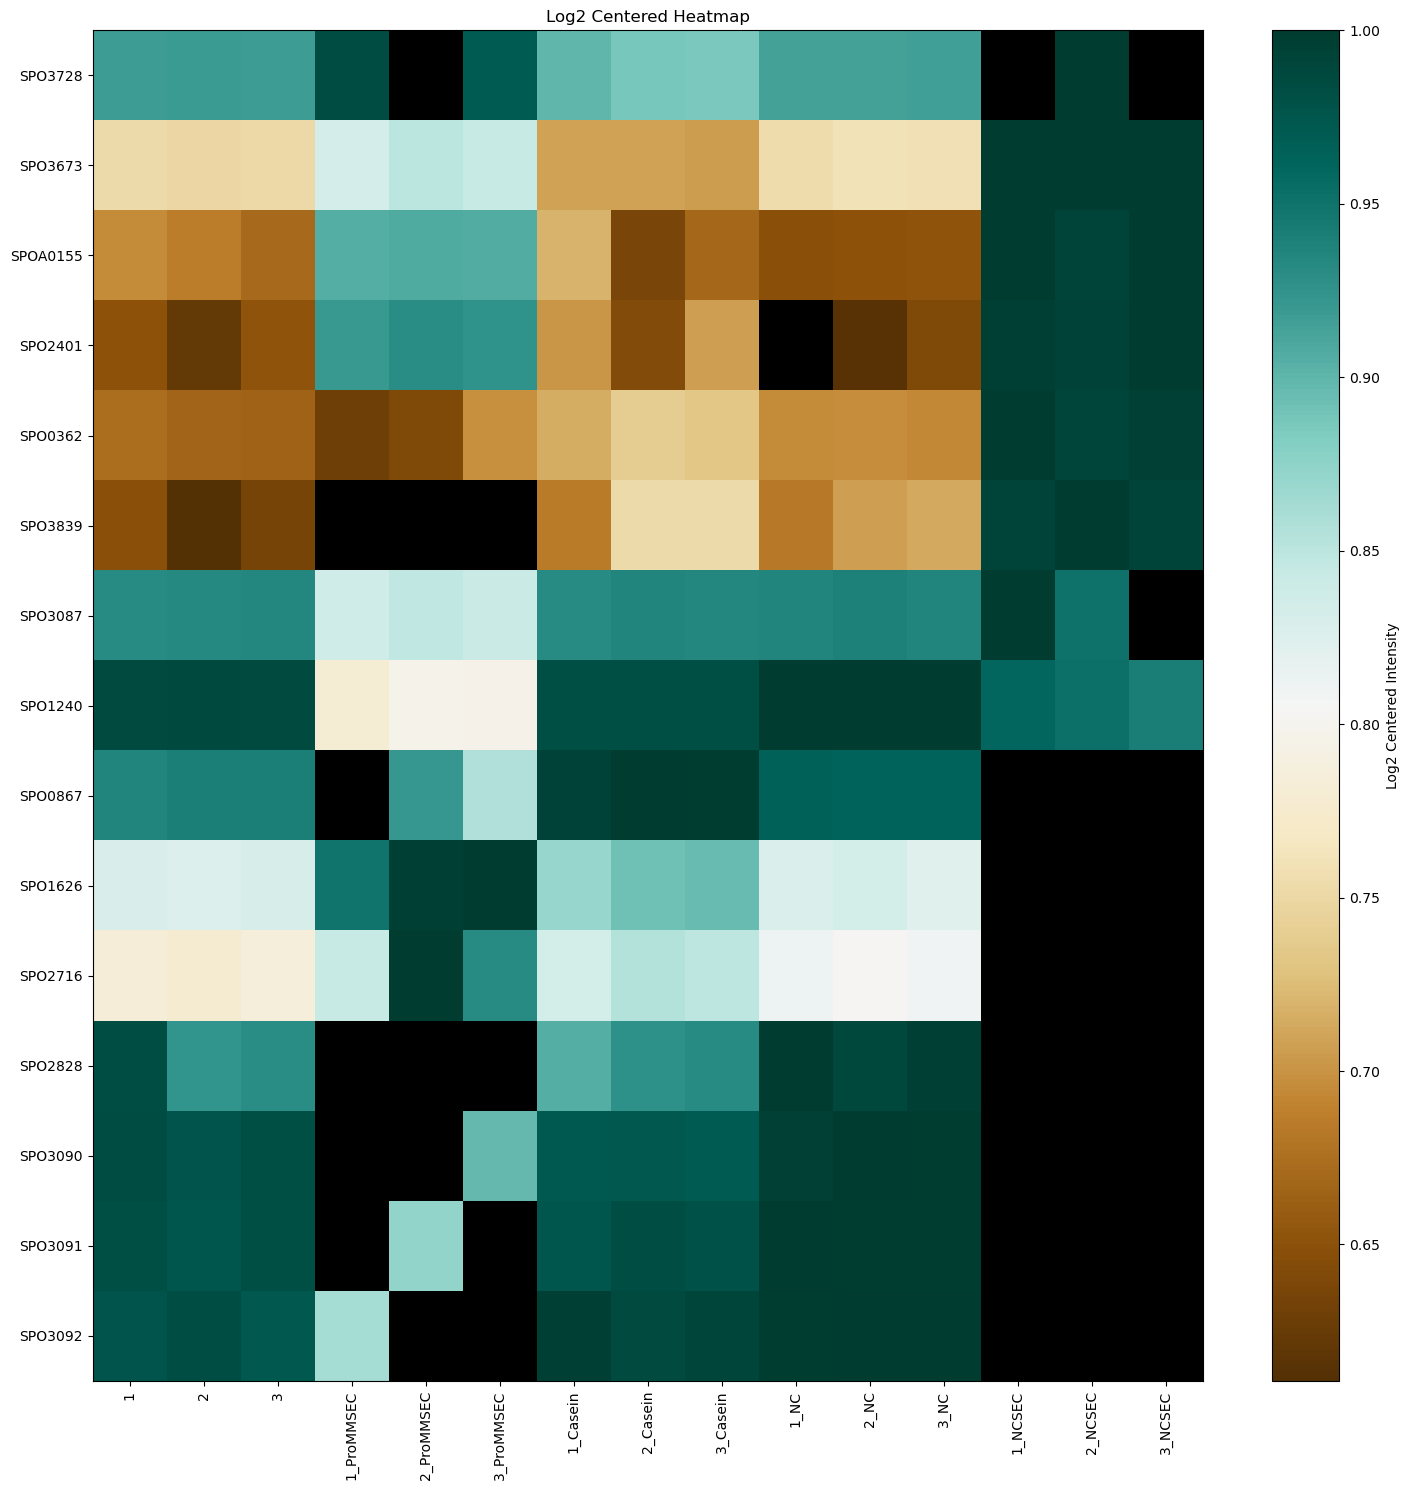

In [17]:
#heatmap(Protease, suffixes, output_filename='heatmap_protease')
#heatmap(Transporter, suffixes, output_filename='heatmap_transporter')
#heatmap(SBP, suffixes, output_filename='heatmap_SBP')
#heatmap(AA, suffixes, output_filename='heatmap_aminoacid')
heatmap(secretion, suffixes, output_filename='heatmap_secretionproteins')
#heatmap(spermidine, suffixes, output_filename='heatmap_spermidine')
#heatmap(decarb, suffixes, output_filename='heatmap_decarboxylase')

# Heatmap row wise averaging with euclidean distances

In [51]:
# Load data
ProMM = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM_ML_annotated.txt', delimiter='\t')
ProMMSEC = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM_MLSec_annotated.txt', delimiter='\t')
Casein = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM+Cas_ML_annotated.txt', delimiter='\t') 
NC = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM-N+C_ML_annotated.txt', delimiter='\t')
NCSEC = pd.read_csv('../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/ANNOTATED/20250315_DSS3_ProMM-N+C_MLsec_annotated.txt', delimiter='\t')

# Filter function
def filter_by_keywords(df, keywords):
    pattern = '|'.join(keywords)
    return df[df['Annotation'].str.contains(pattern, case=False, na=False)]

# Apply to data 
# Proteases & Peptidases
ProMM_Protease = filter_by_keywords(ProMM, ['protease', 'peptidase'])
ProMMSEC_Protease = filter_by_keywords(ProMMSEC, ['protease', 'peptidase'])
Casein_Protease = filter_by_keywords(Casein, ['protease', 'peptidase'])
NC_Protease = filter_by_keywords(NC, ['protease', 'peptidase'])
NCSEC_Protease = filter_by_keywords(NCSEC, ['protease', 'peptidase'])

#Transporters
ProMM_Transporter = filter_by_keywords(ProMM, ['transport'])
ProMMSEC_Transporter = filter_by_keywords(ProMMSEC, ['transport'])
Casein_Transporter = filter_by_keywords(Casein, ['transport'])
NC_Transporter = filter_by_keywords(NC, ['transport'])
NCSEC_Transporter = filter_by_keywords(NCSEC, ['transport'])

#SBPs
ProMM_SBP = filter_by_keywords(ProMM, ['solute'])
ProMMSEC_SBP = filter_by_keywords(ProMMSEC, ['solute'])
Casein_SBP = filter_by_keywords(Casein, ['solute'])
NC_SBP = filter_by_keywords(NC, ['solute'])
NCSEC_SBP = filter_by_keywords(NCSEC, ['solute'])

# Amino Acid
ProMM_AA = filter_by_keywords(ProMM, ['amino acid'])
ProMMSEC_AA = filter_by_keywords(ProMMSEC, ['amino acid'])
Casein_AA = filter_by_keywords(Casein, ['amino acid'])
NC_AA = filter_by_keywords(NC, ['amino acid'])
NCSEC_AA = filter_by_keywords(NCSEC, ['amino acid'])

# Secretion
ProMM_sec = filter_by_keywords(ProMM, ['secretion'])
ProMMSEC_sec = filter_by_keywords(ProMMSEC, ['secretion'])
Casein_sec = filter_by_keywords(Casein, ['secretion'])
NC_sec = filter_by_keywords(NC, ['secretion'])
NCSEC_sec = filter_by_keywords(NCSEC, ['secretion'])

#Spermidine/putrescine transport
ProMM_sp = filter_by_keywords(ProMM, ['spermidine'])
ProMMSEC_sp = filter_by_keywords(ProMMSEC, ['spermidine'])
Casein_sp = filter_by_keywords(Casein, ['spermidine'])
NC_sp = filter_by_keywords(NC, ['spermidine'])
NCSEC_sp = filter_by_keywords(NCSEC, ['spermidine'])

# Decarboxylase
ProMM_decarb = filter_by_keywords(ProMM, ['decarboxylase'])
ProMMSEC_decarb = filter_by_keywords(ProMMSEC, ['decarboxylase'])
Casein_decarb = filter_by_keywords(Casein, ['decarboxylase'])
NC_decarb = filter_by_keywords(NC, ['decarboxylase'])
NCSEC_decarb = filter_by_keywords(NCSEC, ['decarboxylase'])


#Create Lists of functionalities
#PPT = [ProMM_PPT, ProMMSEC_PPT, Casein_PPT, NC_PPT, NCSEC_PPT]
Protease = [ProMM_Protease, ProMMSEC_Protease, Casein_Protease, NC_Protease, NCSEC_Protease]
Transporter = [ProMM_Transporter, ProMMSEC_Transporter, Casein_Transporter, NC_Transporter, NCSEC_Transporter]
SBP = [ProMM_SBP, ProMMSEC_SBP, Casein_SBP, NC_SBP, NCSEC_SBP]
AA = [ProMM_AA, ProMMSEC_AA, Casein_AA, NC_AA, NCSEC_AA]
secretion = [ProMM_sec, ProMMSEC_sec, Casein_sec, NC_sec, NCSEC_sec]
spermidine = [ProMM_sp, ProMMSEC_sp, Casein_sp, NC_sp, NCSEC_sp]
decarb = [ProMM_decarb, ProMMSEC_decarb, Casein_decarb, NC_decarb, NCSEC_decarb]
suffixes = ['ProMM', 'ProMMSEC', 'Casein', 'NC', 'NCSEC']

def heatmap(dfs, suffixes, output_filename=''):
    # Merge all datasets on ['Accession Number', 'Annotation']
    merged = dfs[0]
    for df, suffix in zip(dfs[1:], suffixes[1:]):
        merged = pd.merge(merged, df, on=['Accession Number', 'Annotation'], suffixes=('', f'_{suffix}'))
        merged = merged.sort_values(by='Accession Number')

    # Drop non-numeric columns
    numeric_data = merged.drop(['Accession Number', 'Annotation'], axis=1)

    # Log2 transform and median centering (row-wise; for column-wise switch 0 and 1 in axis attribute)
    log2_data = np.log2(numeric_data) # take the log2 of all the data
    log2_data_centered = log2_data.sub(log2_data.median(axis=1), axis=0) # takes the row-wise average - median(axis=1) - and then substracts the row median from each row.

    # Sort by NCSEC average intensity
    NCSEC_cols = [col for col in log2_data_centered.columns if 'NCSEC' in col]
    NCSEC_mean = log2_data_centered[NCSEC_cols].mean(axis=1)
    sort_order = NCSEC_mean.sort_values(ascending=False).index
    log2_data_centered_sorted = log2_data_centered.loc[sort_order]
    merged_sorted = merged.loc[sort_order]

    # Drop rows with NaNs for clustering
    heatmap_data = log2_data_centered_sorted.fillna(0)

    # Use Accession Numbers as row labels
    row_labels = merged_sorted.loc[heatmap_data.index, 'Accession Number']

    # Create colormap with black for NaNs
    cmap = plt.cm.BrBG
    cmap.set_bad(color='black')

    # Create clustermap with Euclidean distance
    sns.set(font_scale=0.8)
    g = sns.clustermap(
        heatmap_data,
        metric='euclidean',
        method='average',
        cmap=cmap,
        figsize=(15, 15),
        xticklabels=True,
        yticklabels=row_labels.tolist()
    )

    plt.suptitle('Hierarchical Heatmap (Euclidean Distance, Log2 Centered)', y=1.02)
    
    if output_filename:
        g.savefig(f'../../../Projects/GENERALS PAPER/GENERALS FIGURES/heat_row/{output_filename}.pdf', format='pdf', dpi=300)
    
    plt.show()

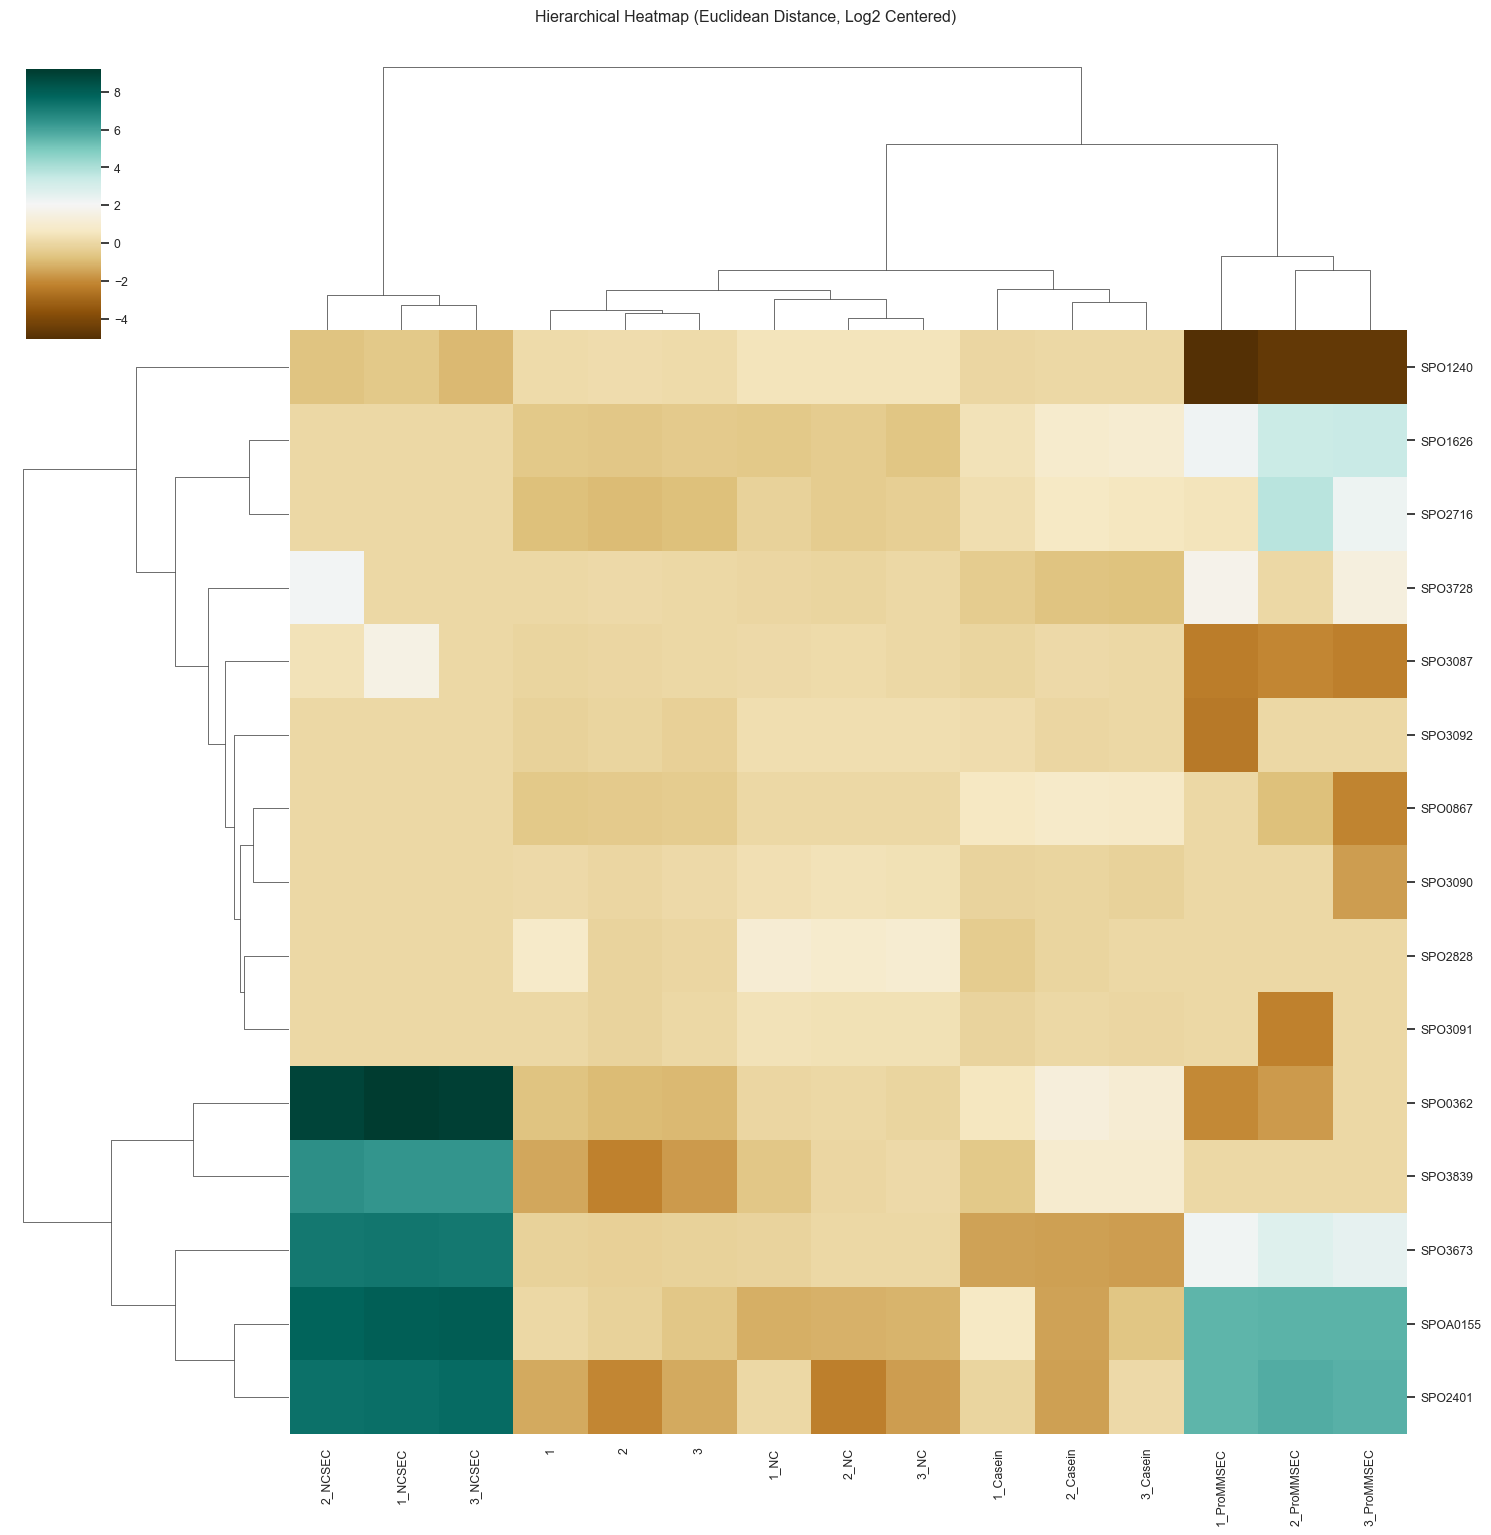

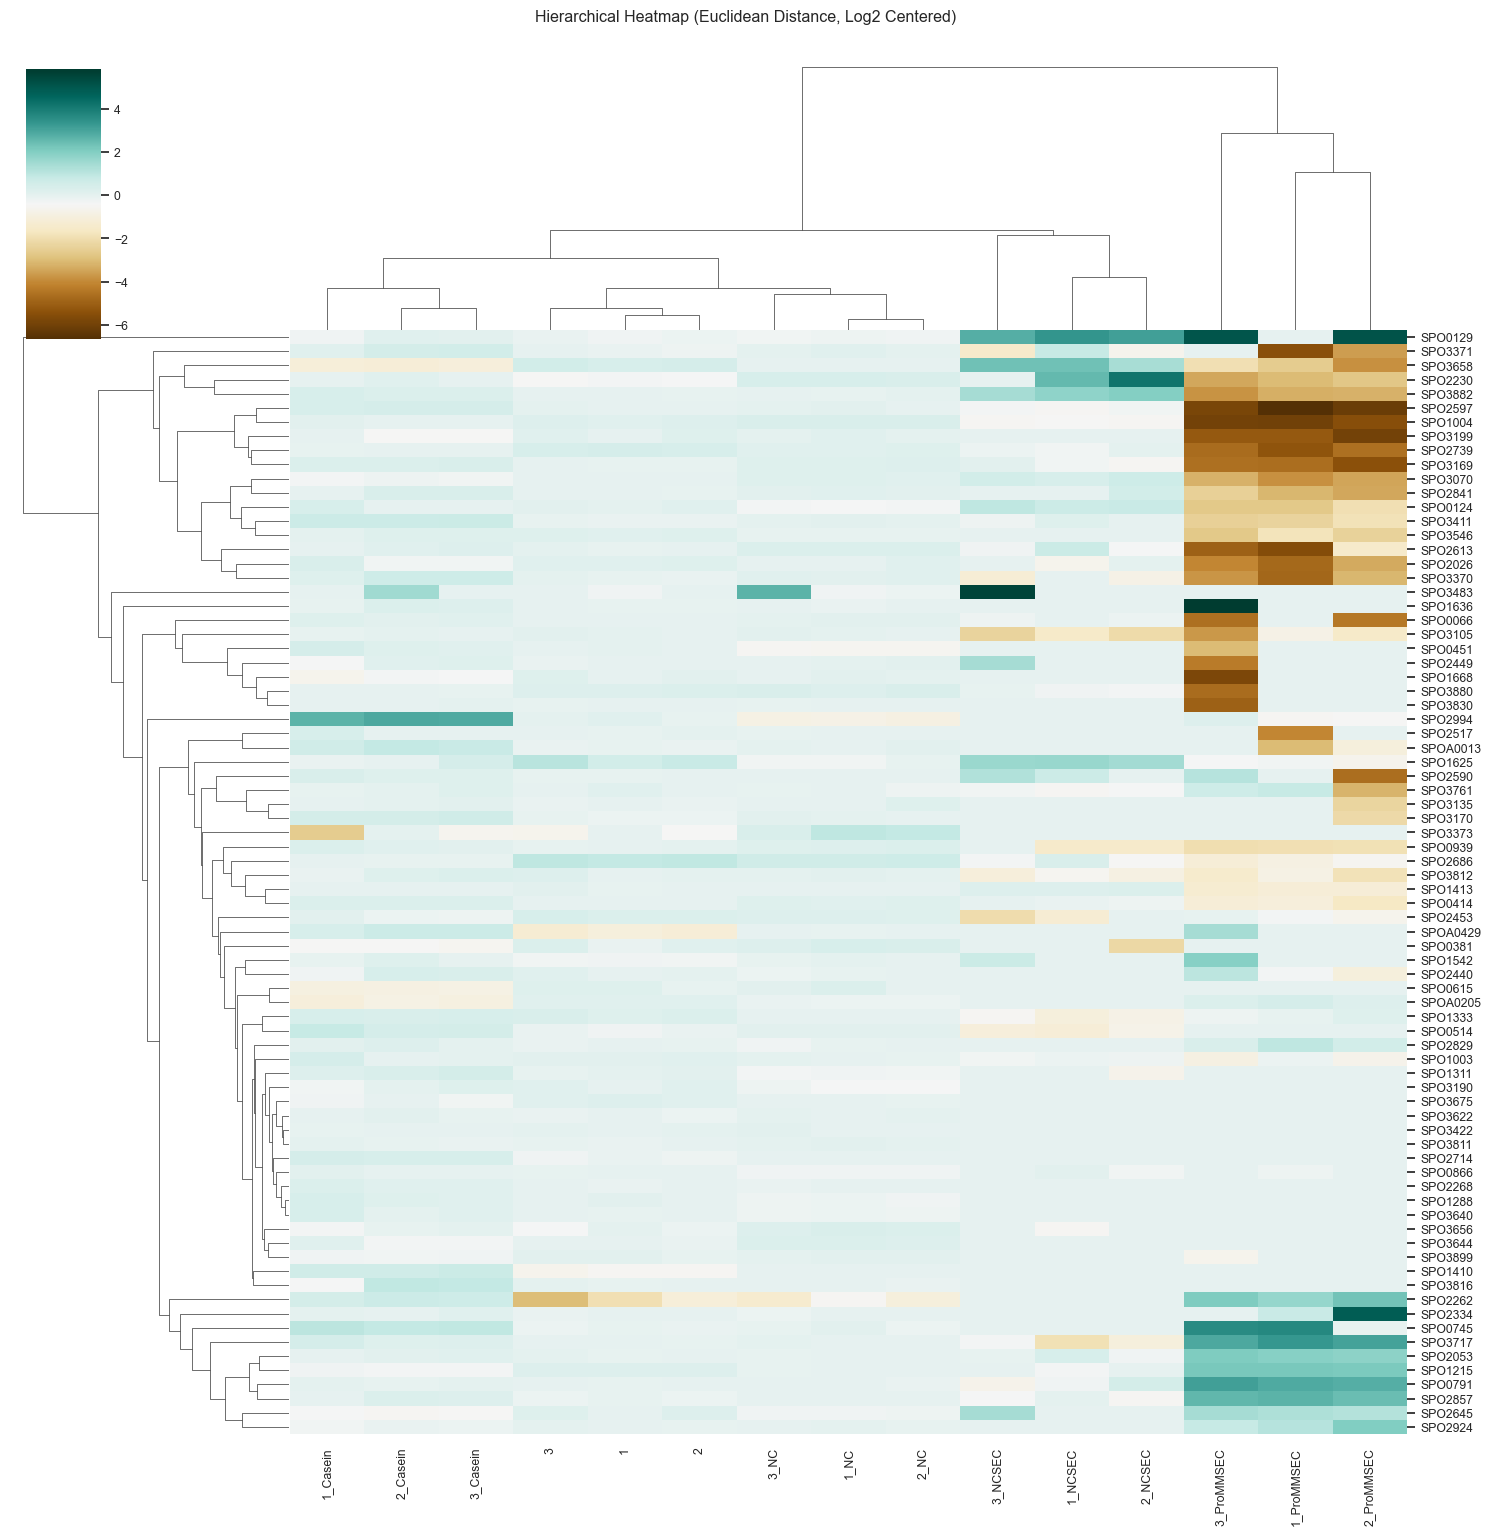

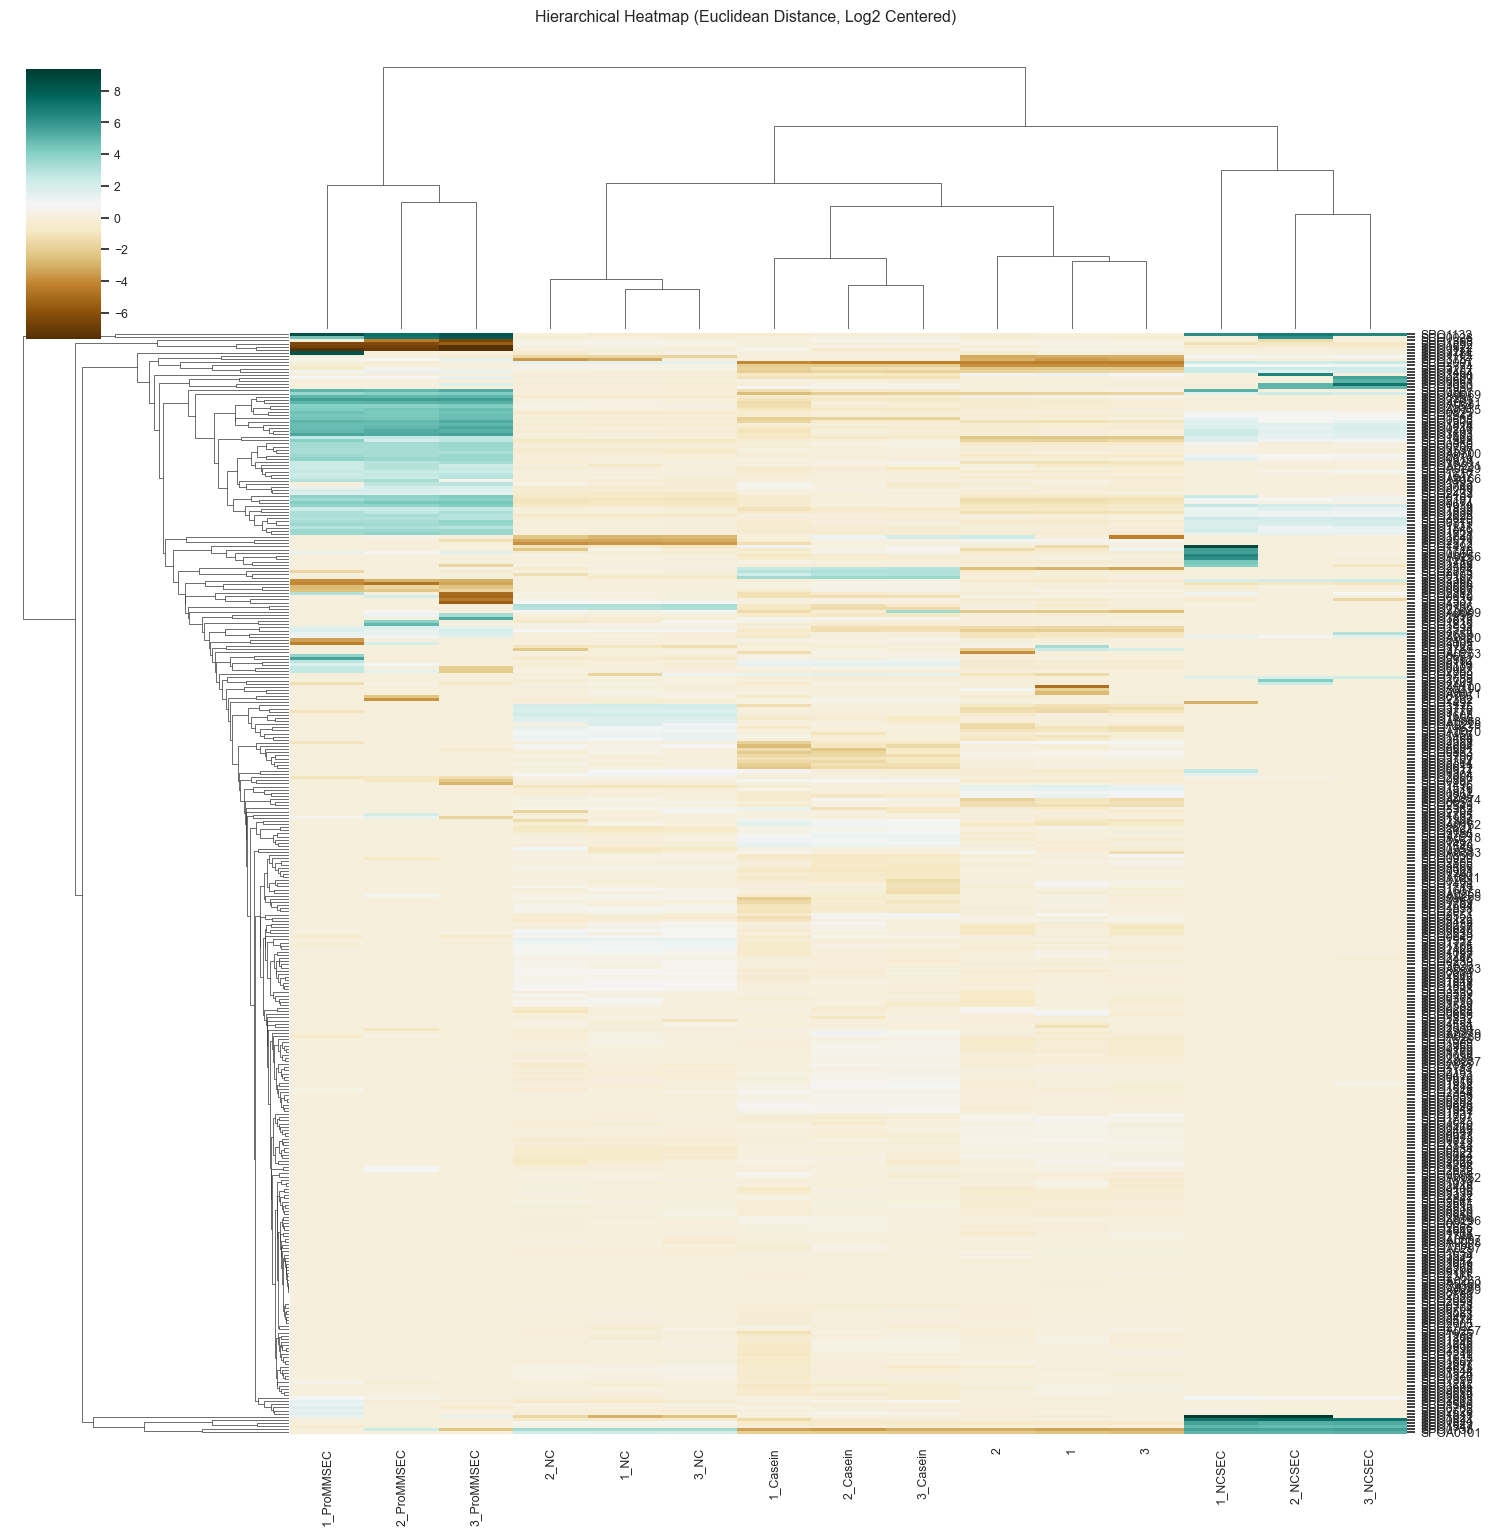

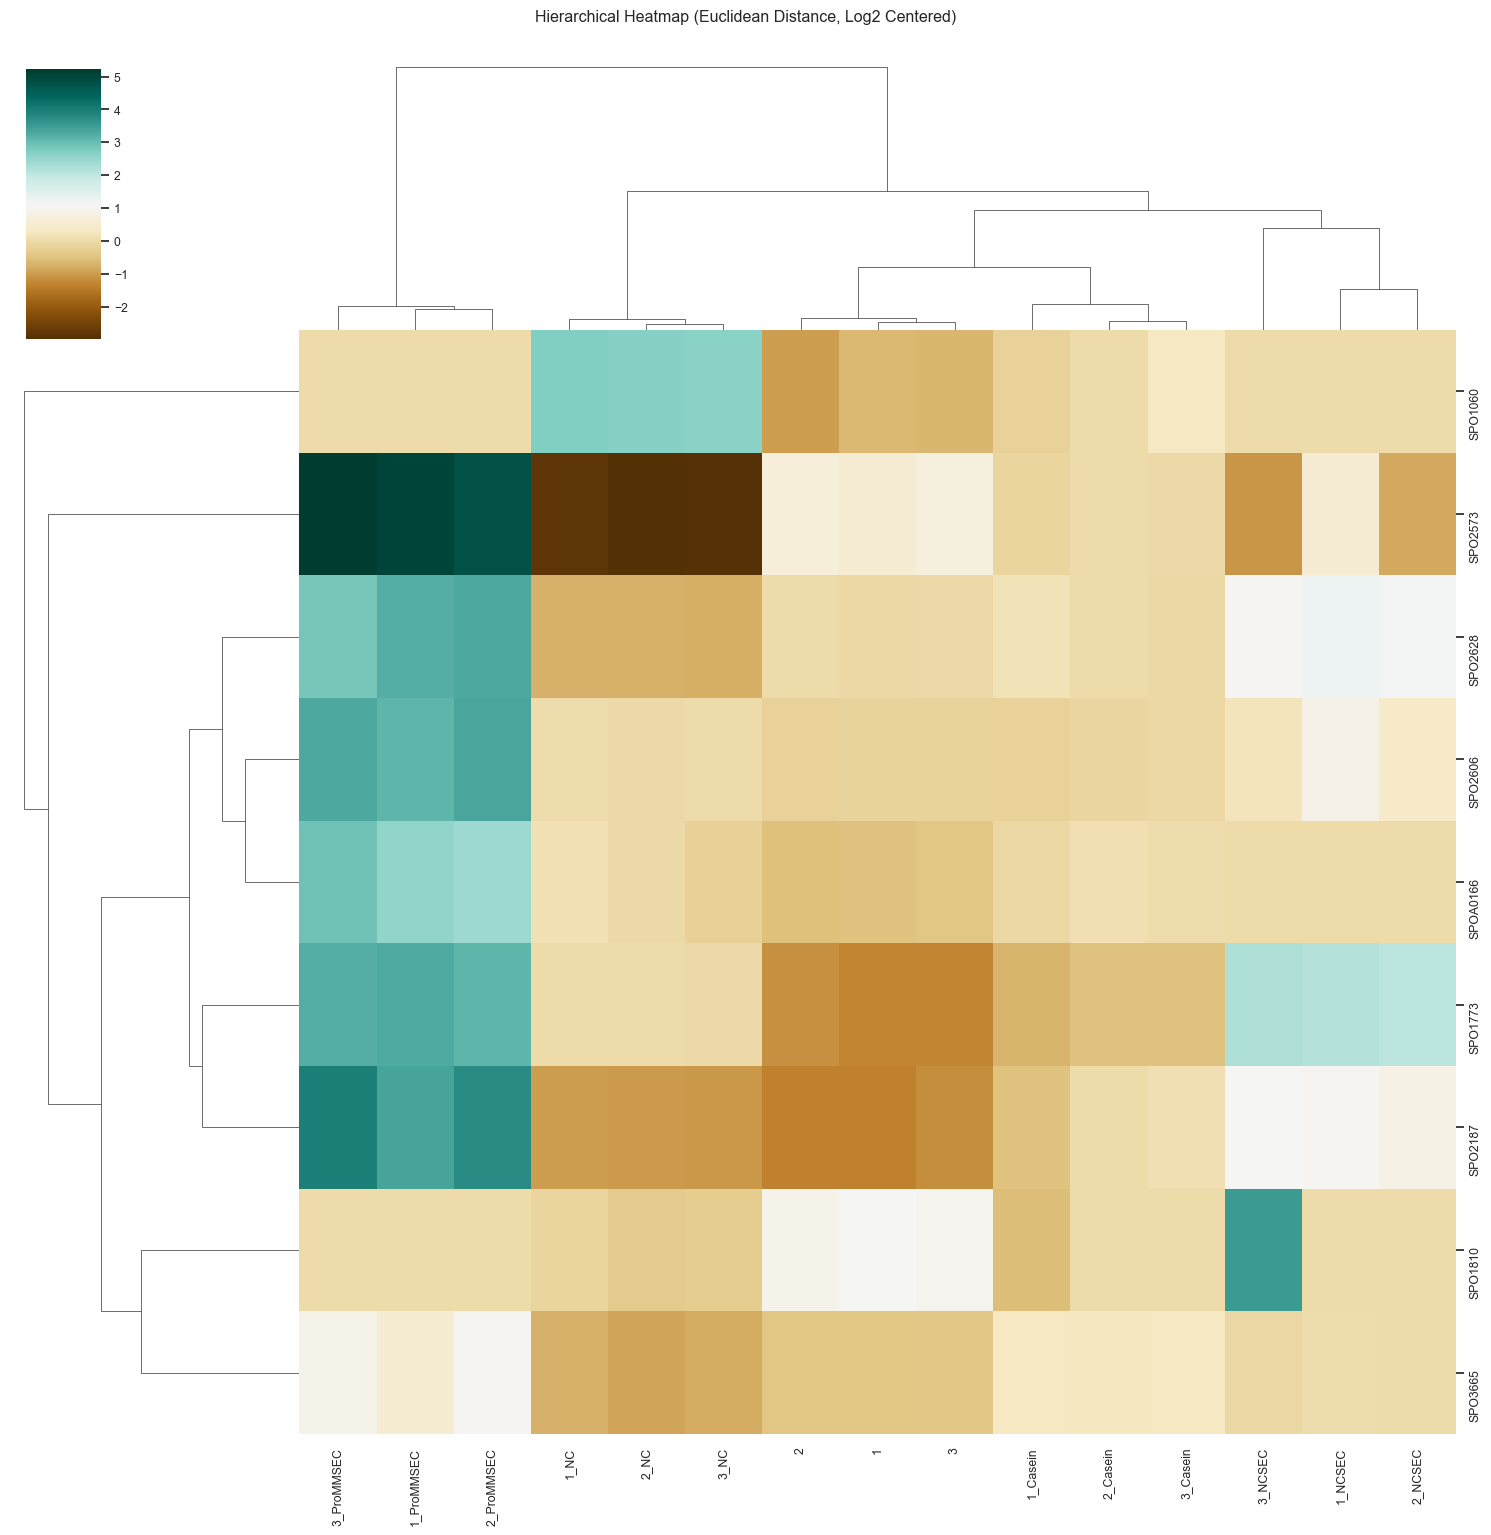

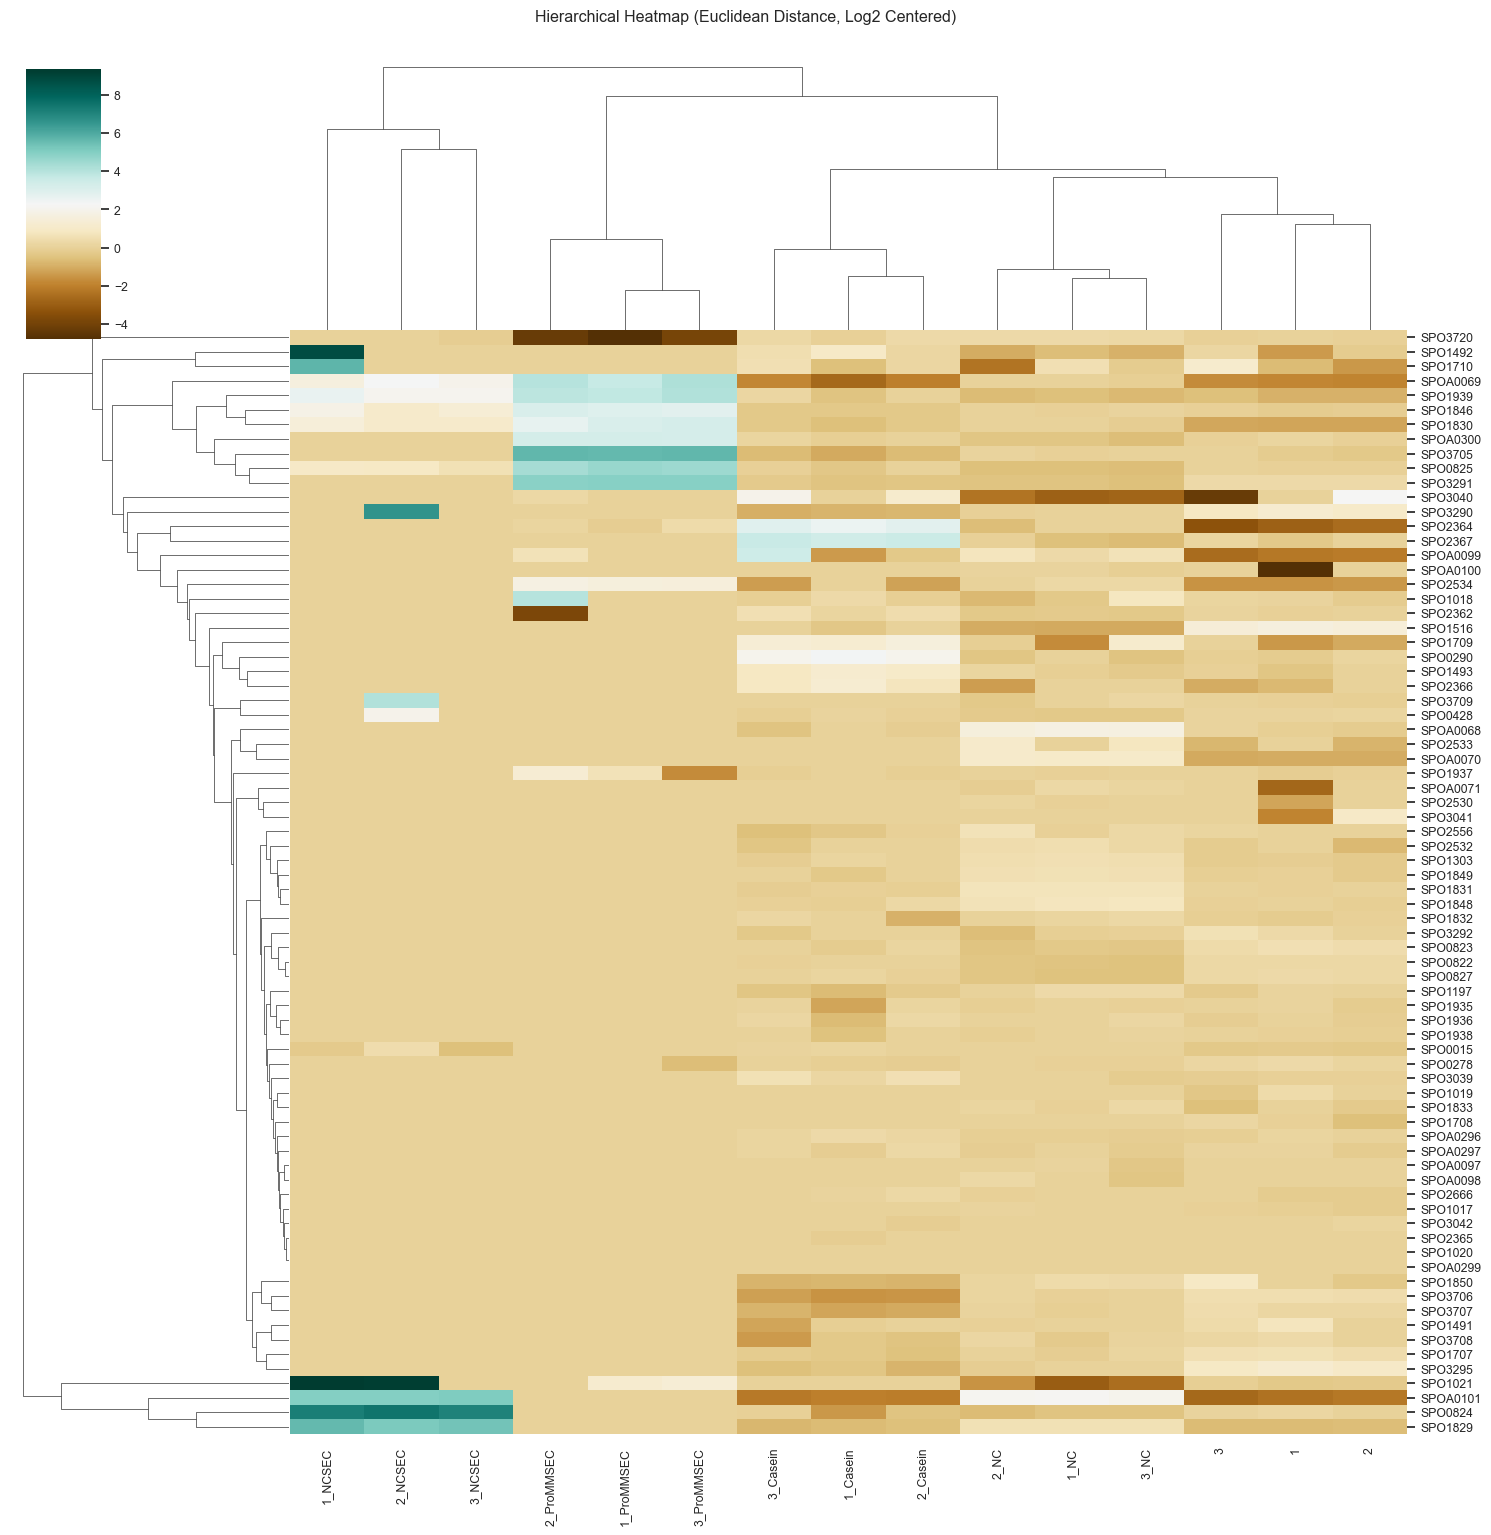

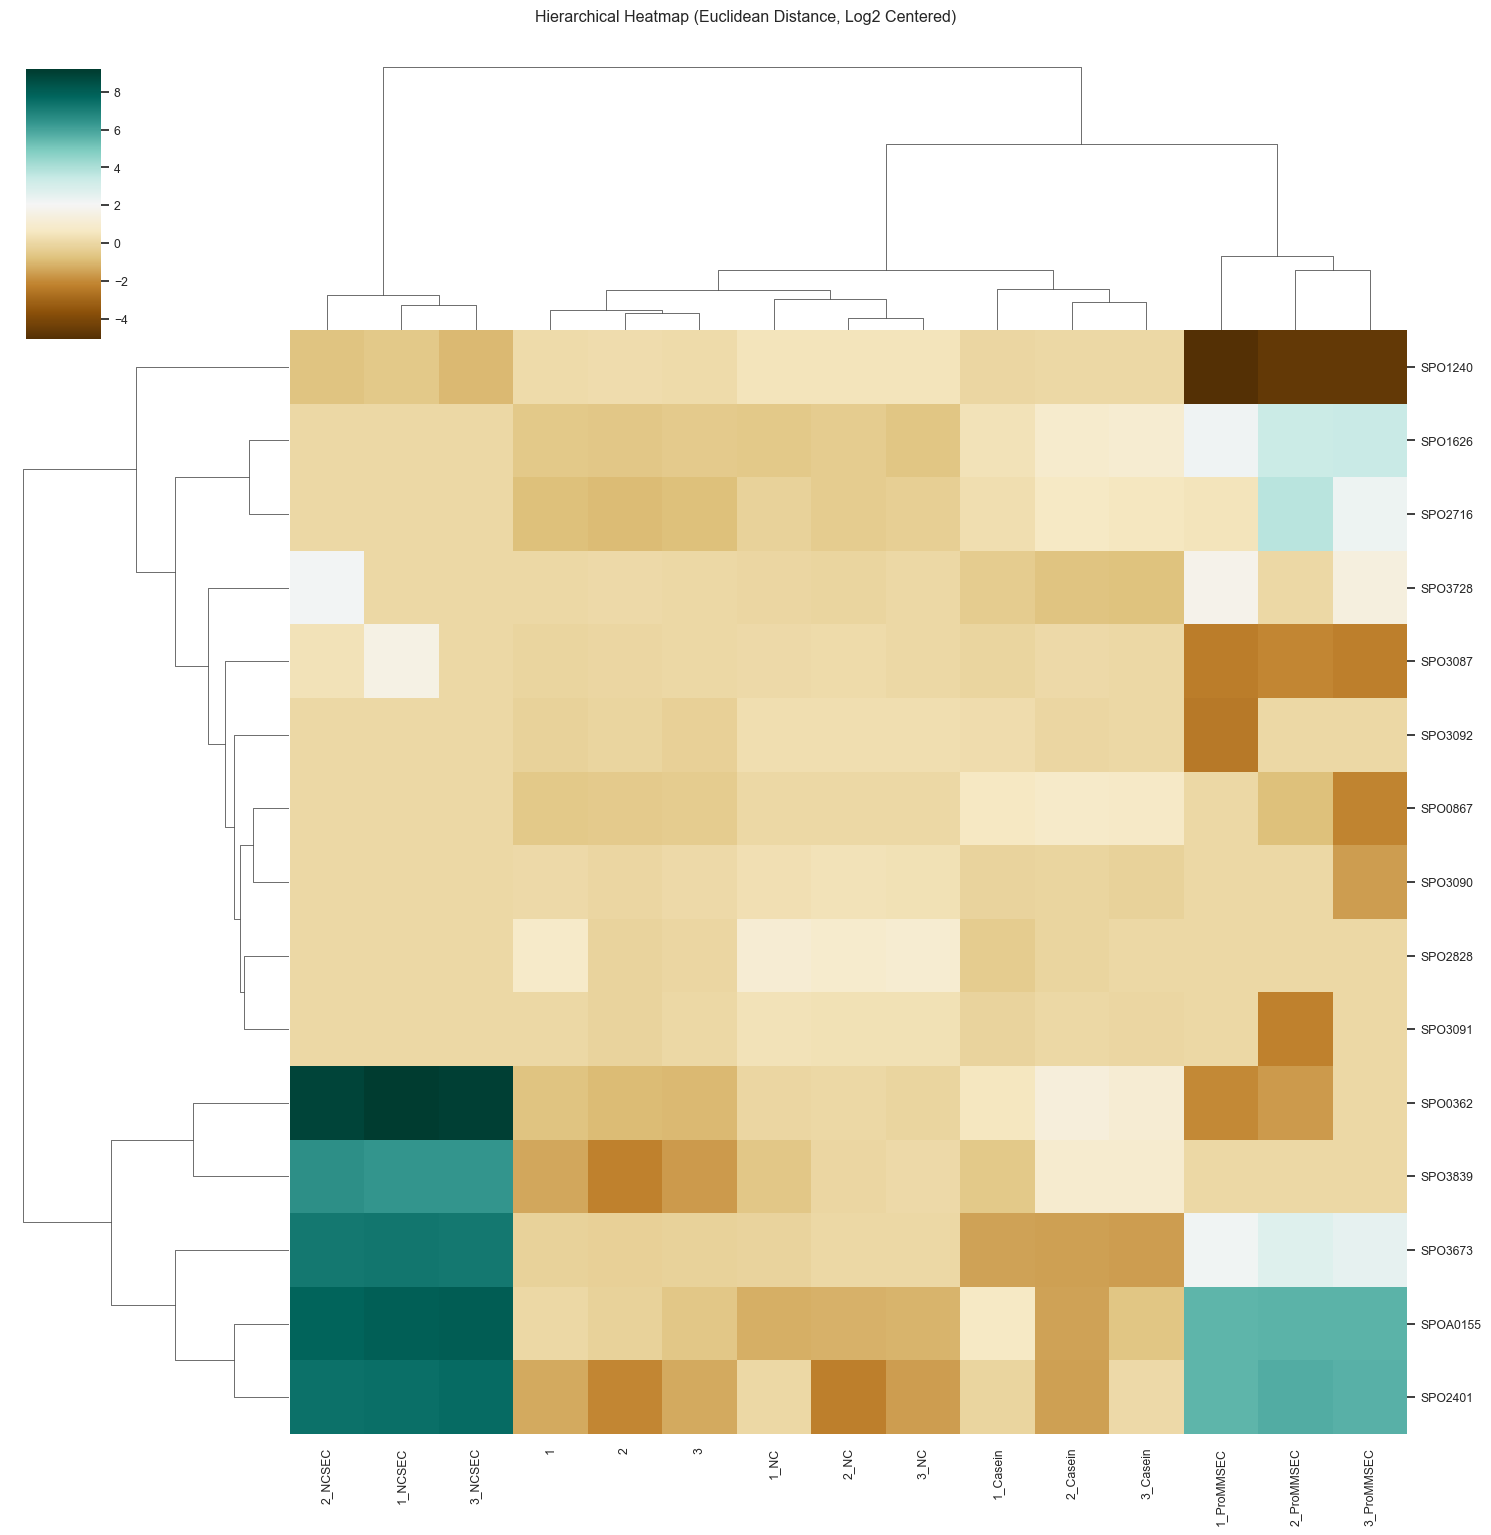

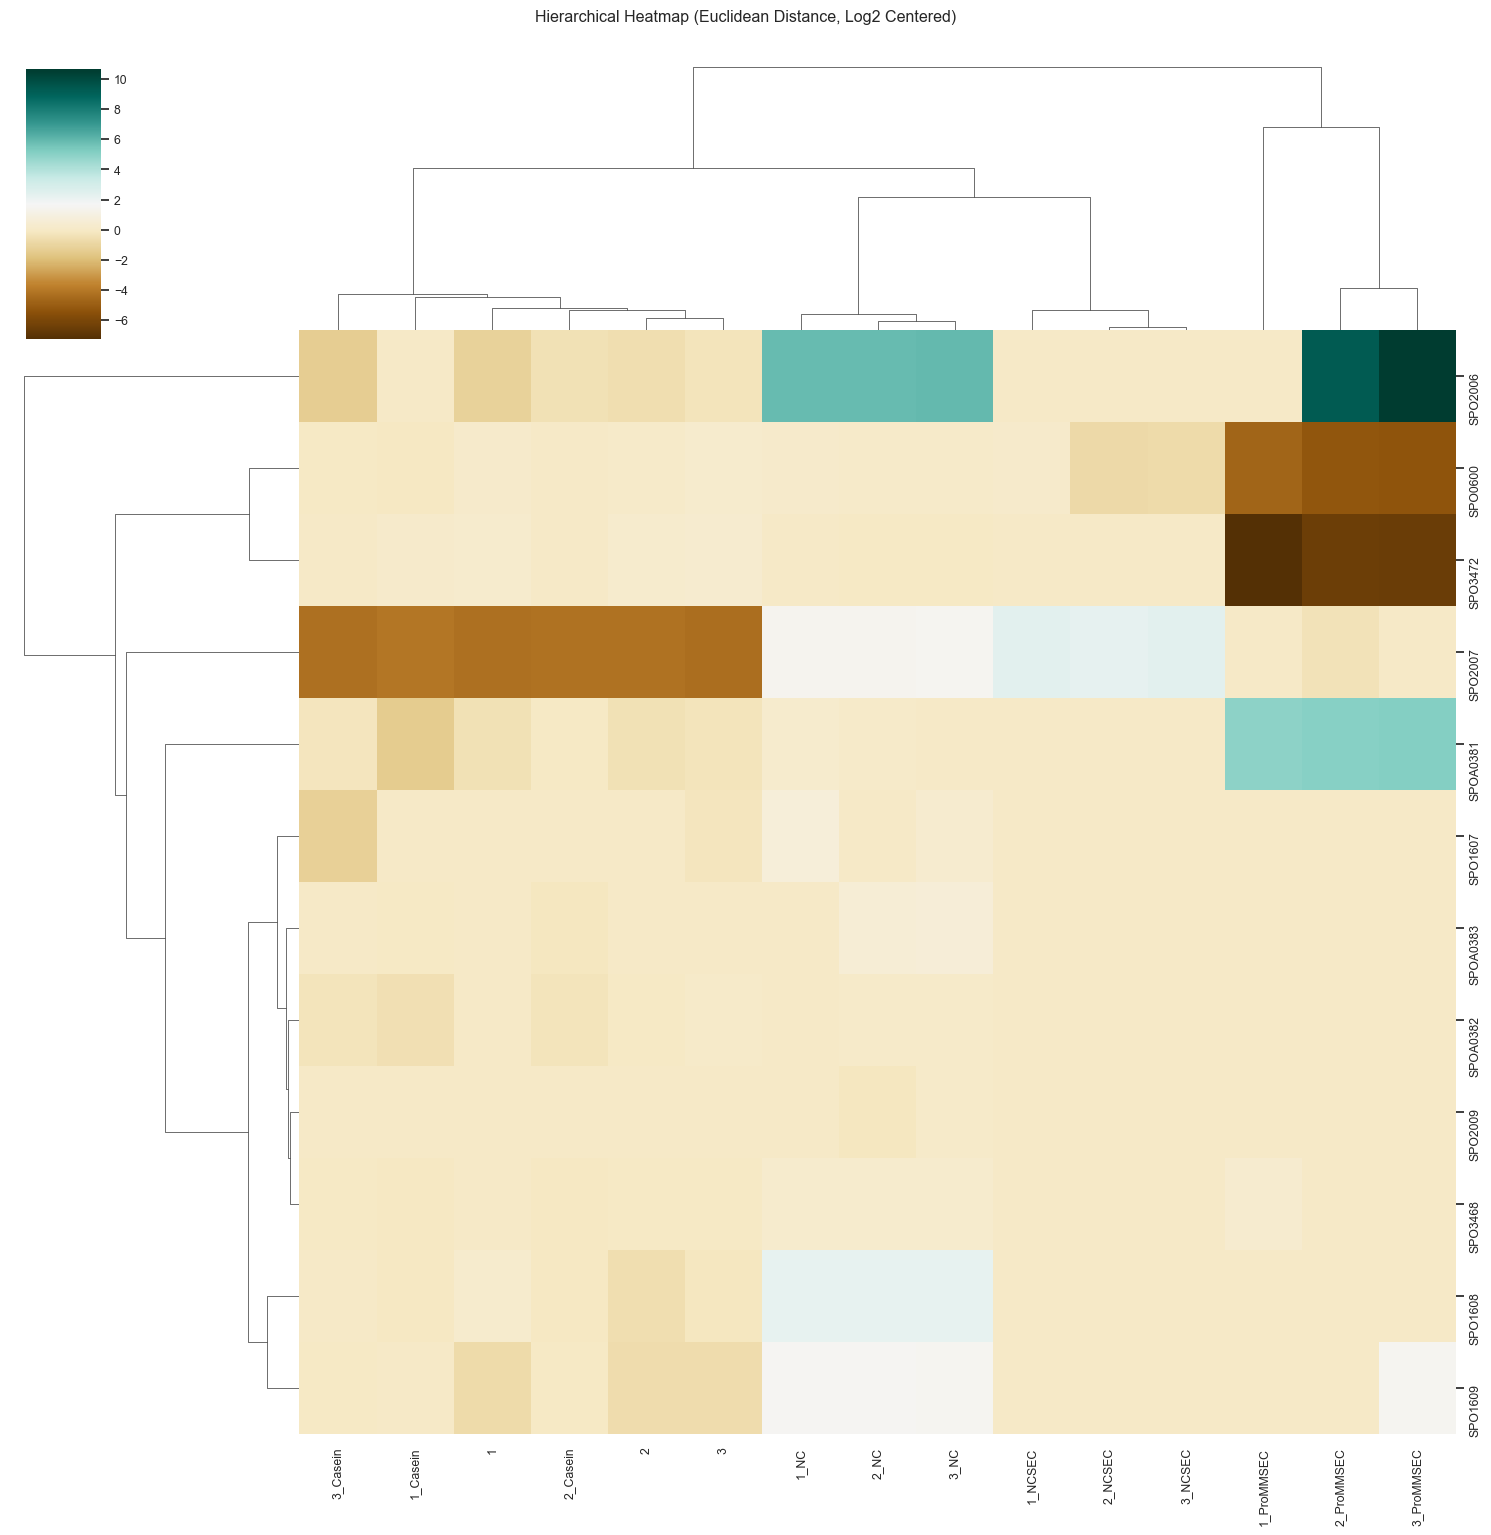

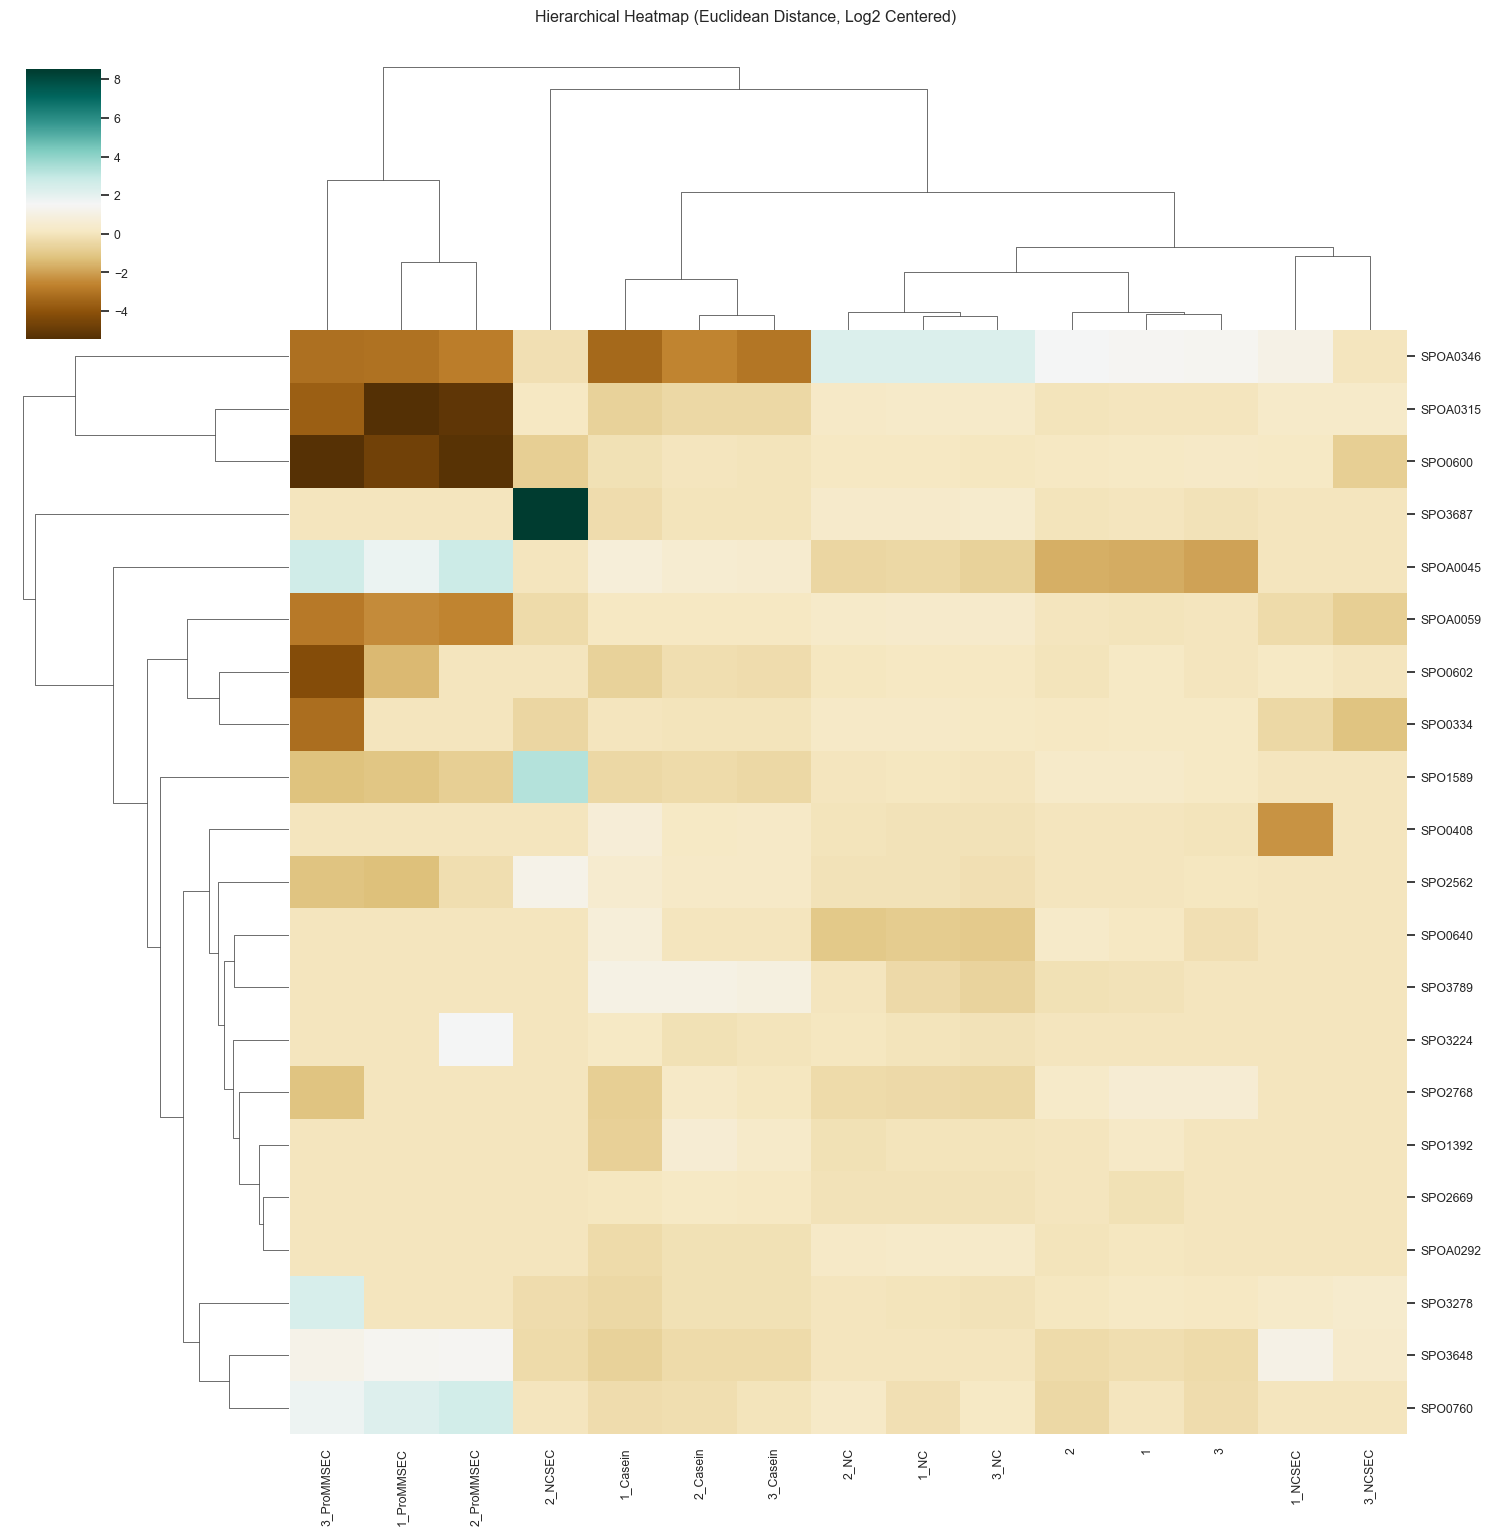

In [14]:
heatmap(secretion, suffixes, output_filename='heatmap_secretionproteins_euclidean')
heatmap(Protease, suffixes, output_filename='heatmap_protease')
heatmap(Transporter, suffixes, output_filename='heatmap_transporter')
heatmap(SBP, suffixes, output_filename='heatmap_SBP')
heatmap(AA, suffixes, output_filename='heatmap_aminoacid')
heatmap(secretion, suffixes, output_filename='heatmap_secretionproteins')
heatmap(spermidine, suffixes, output_filename='heatmap_spermidine')
heatmap(decarb, suffixes, output_filename='heatmap_decarboxylase')

# Bar plot of abundances

In [17]:
# This is just abundance of each protein annotation per medium
from bokeh.palettes import Set3

# Output HTML file
output_file("../../../../protein_abundances.html")

# Load the data
df = pd.read_csv('../../../abundance.txt', sep='\t')

# Set 'Annotation' as index
df.set_index('Annotation', inplace=True)

# Get list of sample columns and protein annotations
samples = df.columns.values
proteins = df.index.unique()

# Group by annotation and sum across rows with the same annotation
df = df.groupby(df.index)[samples].sum()

# Assign a color to each protein (cycling through Spectral palette if needed)
color_iter = itertools.cycle(Viridis[11])  # Insert number of colors in prentheses https://docs.bokeh.org/en/latest/docs/reference/palettes.html
colors = [next(color_iter) for _ in proteins]

# Construct ColumnDataSource dictionary
data = {'samples': list(samples)}
for protein in proteins:
    data[protein] = list(df.loc[protein])

# Create ColumnDataSource for Bokeh
source = ColumnDataSource(data=data)

# Create the stacked bar plot
p = figure(x_range=list(samples), height=400, title="Protein abundance by annotation",
           toolbar_location=None, tools="")

# Stacked bars
p.vbar_stack(list(proteins), x='samples', width=0.9, source=source,
             legend_label=list(proteins), color=colors)

# Axis labels
p.xaxis.axis_label = 'Sample'
p.yaxis.axis_label = 'Abundance'

# Legend formatting
p.legend.orientation = "vertical"
p.add_layout(p.legend[0], 'right')

# Show the result
show(p)

FileNotFoundError: [Errno 2] No such file or directory: '../../../../abundance.txt'

In [48]:
def plot_spectral_counts(filename, spo_accession, output_filename=''):
    # Load file
    df = pd.read_csv(filename, sep='\t')
    
    # Set Protein.Group as index for easy lookup
    df.set_index('Protein.Group', inplace=True)
    
    # Check if the accession exists
    if spo_accession not in df.index:
        print(f"{spo_accession} not found in file.")
        return
    
    # Extract the row for the selected accession
    row = df.loc[spo_accession]
    
    # Create groups of triplicates
    triplicate_groups = {
        'ProMM_ML': ['ProMM_ML_1', 'ProMM_ML_2', 'ProMM_ML_3'],
        'ProMM_Sec_ML': ['ProMM_Sec_ML_I', 'ProMM_Sec_ML_II', 'ProMM_Sec_ML_III'],
        'Cas_ML': ['Cas_ML_I', 'Cas_ML_II', 'Cas_ML_III'],
        'NC_ML': ['NC_ML_I', 'NC_ML_II', 'NC_ML_III'],
        'NC_Sec_ML': ['NC_Sec_ML_I', 'NC_Sec_ML_II', 'NC_Sec_ML_III']
    }
    
    means = []
    stds = []
    conditions = []
    
    for condition, cols in triplicate_groups.items():
        try:
            values = row[cols].astype(float)
            means.append(values.mean())
            stds.append(values.std())
            conditions.append(condition)
        except KeyError:
            print(f"Some columns missing for condition: {condition}")
    
    # Plot
    fig, ax = plt.subplots()
    cmap = plt.colormaps['viridis']
    colors = cmap(np.linspace(0, 0.8, len(conditions)))
    
    bars = ax.bar(conditions, means, yerr=stds, capsize=5, color=colors)
    
    ax.set_ylabel('Normalized Peak Area [10^10]')
    ax.set_ylim(0,5e5)
    ax.set_title(f'{spo_accession}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    if output_filename: 
        plt.savefig(f'{output_filename}.pdf', format='pdf')
    plt.show()

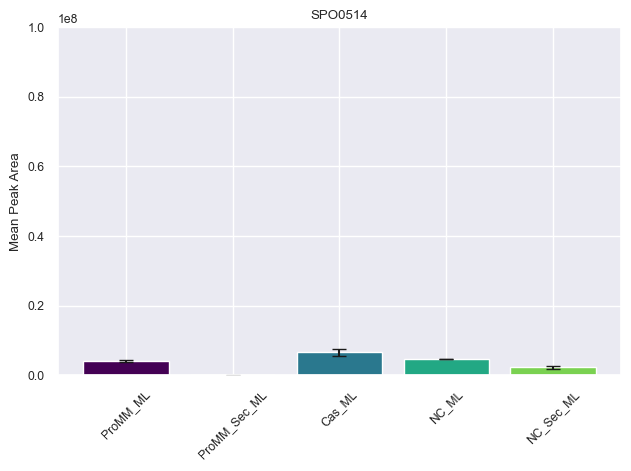

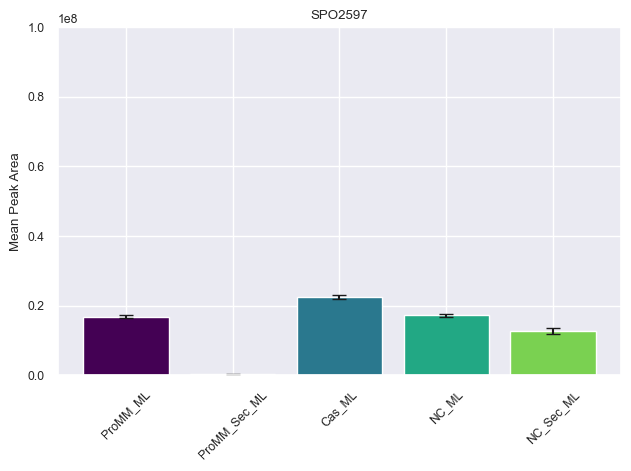

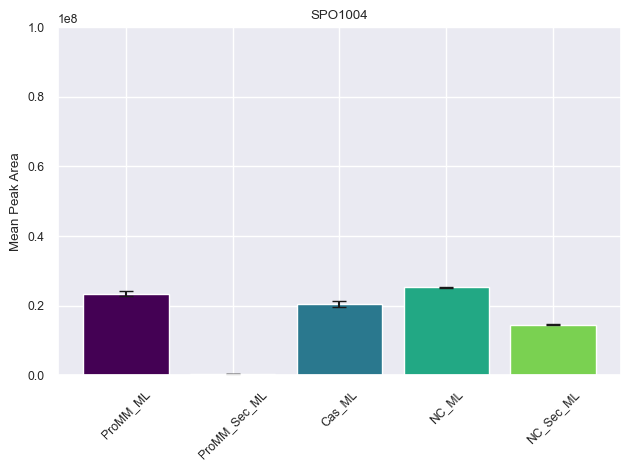

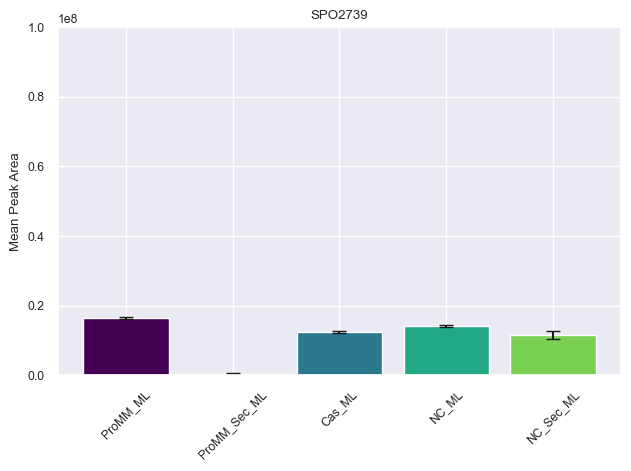

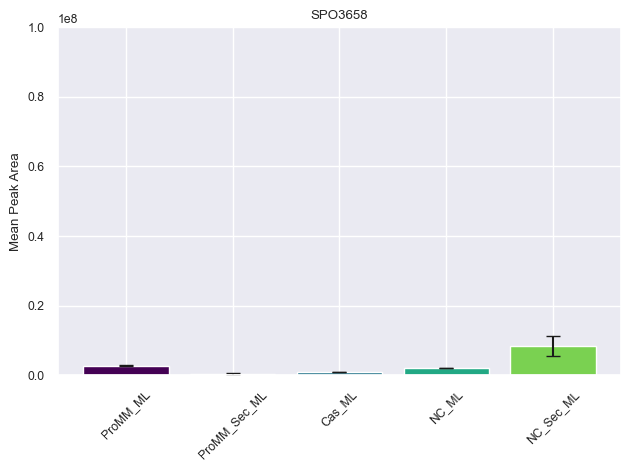

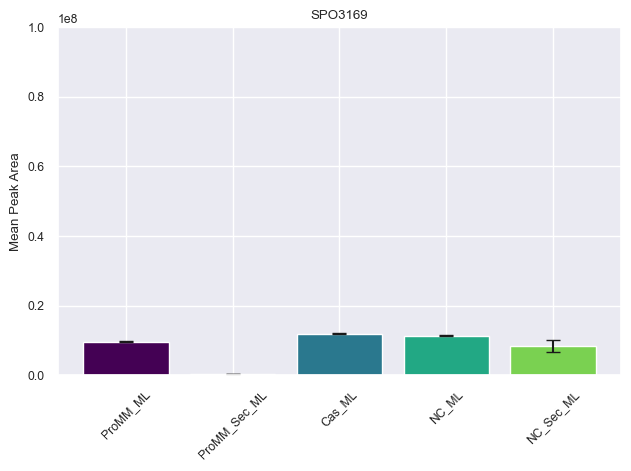

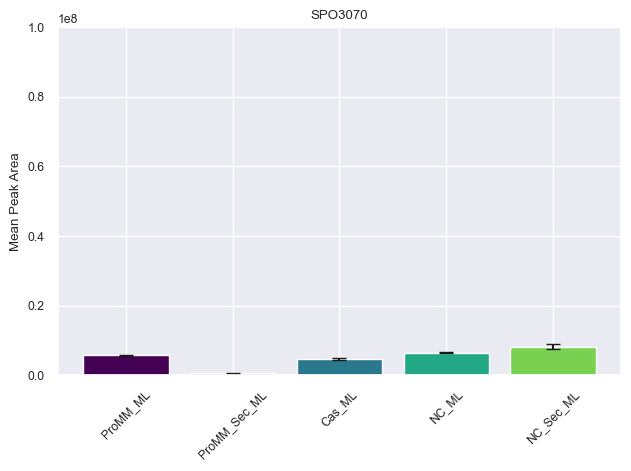

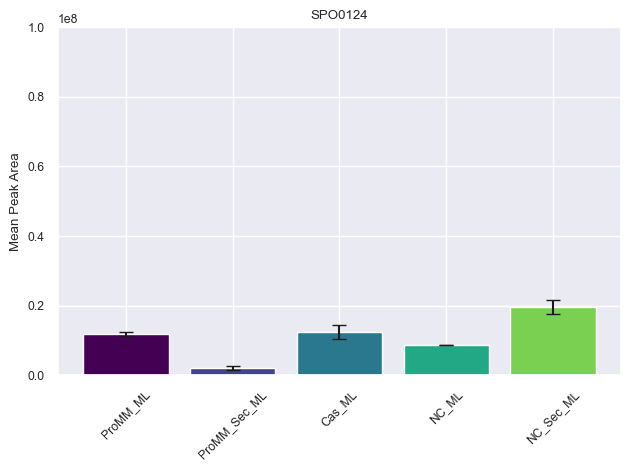

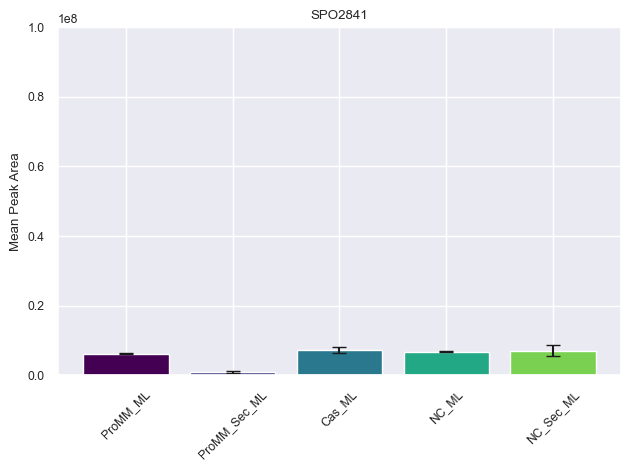

In [19]:
# Proteases in NC SEC
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0514", output_filename='bar_plots/SPO0514')
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2597", output_filename='bar_plots/SPO2597')
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO1004", output_filename='bar_plots/SPO1004')
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2739", output_filename='bar_plots/SPO2739')
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3658", output_filename='bar_plots/SPO3658')
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3169", output_filename='bar_plots/SPO3169')
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3070", output_filename='bar_plots/SPO3070')
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0124", output_filename='bar_plots/SPO0124')
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2841", output_filename='bar_plots/SPO2841')


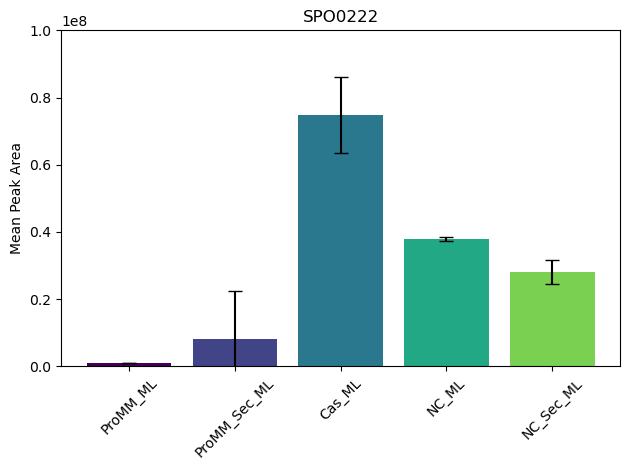

In [34]:
# Proteins abundant in NC (Intra)
# TRAP
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0738", output_filename='bar_plots/SPO0738')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0736", output_filename='bar_plots/SPO0736')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO1463", output_filename='bar_plots/SPO1463')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO1465", output_filename='bar_plots/SPO1465')


# ABC

#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPOA0098", output_filename='bar_plots/SPOA0098')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPOA0097", output_filename='bar_plots/SPOA0097')

#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3774", output_filename='bar_plots/SPO3774')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3776", output_filename='bar_plots/SPO3776')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPOA0099", output_filename='bar_plots/SPOA0099')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPOA0101", output_filename='bar_plots/SPOA0101')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3777", output_filename='bar_plots/SPO3777')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3778", output_filename='bar_plots/SPO3778')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPOA0070", output_filename='bar_plots/SPOA0070')

# Spermidine
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO1608", output_filename='bar_plots/SPO1608')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2007", output_filename='bar_plots/SPO2007')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2009", output_filename='bar_plots/SPO2009')

# Dehydrogenases
plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0222", output_filename='bar_plots/SPO0222')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0235", output_filename='bar_plots/SPO0235')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0390", output_filename='bar_plots/SPO0390')


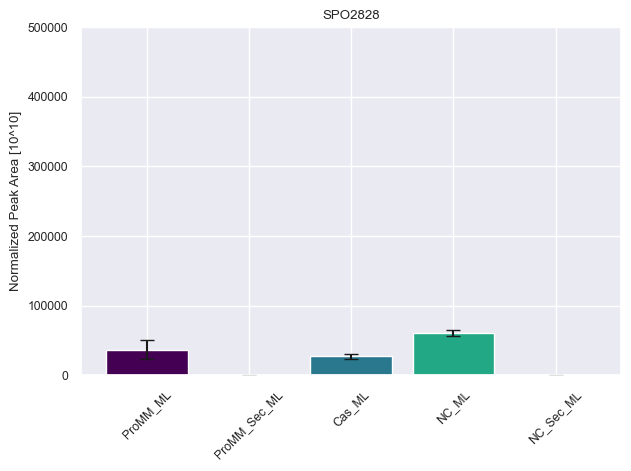

In [49]:
# Proteins abundant in NC SEC 
# - T1SS
#plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0362", output_filename='../figures/SPO0362')
#plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3673", output_filename='../figures/SPO3673')
#plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPOA0155", output_filename='../figures/SPOA0155')
#plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO1240", output_filename='../figures/SPO1240')
#plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3839", output_filename='../figures/SPO3839')
#plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO1626", output_filename='../figures/SPO1626')
#plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2716", output_filename='../figures/SPO2716')
#plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3728", output_filename='../figures/SPO3728')
plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2828", output_filename='../figures/SPO2828')
#plot_spectral_counts("../../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2401", output_filename='../figures/SPO2401')


# - ABC amino acid
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0824", output_filename='bar_plots/SPO0824')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO1829", output_filename='bar_plots/SPO1829')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPOA0101", output_filename='bar_plots/SPOA0101')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0522", output_filename='bar_plots/SPO0522')

# Tim44
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO3886", output_filename='bar_plots/SPO3886')

# Spermidine
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2007", output_filename='bar_plots/SPO2007')
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO2006", output_filename='bar_plots/SPO2006')

# Oligopeptide
#plot_spectral_counts("../../Projects/PROTEOMES_HETEROTROPHS/Data/Proteomes/20250315_Fragpipe_DSS3/FRAGPIPE_OUTPUT/SUMMARY_PROTEOMES.txt", "SPO0560", output_filename='bar_plots/SPO0560')
